# Totten Icequake Analysis

**Jared C. Magyar 2025**

## Seismicity of Totten Glacier

Before analysis of any particular events, a broad survey of the seismicity of the glacier can be made. Here, I first focus on the occurence of impulsive events, but tremor analysis is also an avenue of work which could provide insights on meltwater flux through the glacier.

The Totten Glacier deployment consists of 12 broadband seismic stations, although these are situated in 6 general sites with three of these being station triplets. These triplet stations are denoted as 'A', 'B' and 'C'. When making an event catalogue and undertaking waveform analysis for the entire network, I only use the 6 'A' stations. The 'B' and 'C' stations are useful for considering local seismic sources and aiding in localisation of these. I therefore use these to form event catalogues around each of these sites.

In [73]:
import numpy as np
import xarray as xr
from obspy.core.inventory import inventory
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from cryoquake import event_calculation as ec
from cryoquake import moment_magnitude as mm
from obspy.core import UTCDateTime, read, Stream, Trace
import matplotlib.pyplot as plt
import obspy
from obspy.signal.filter import envelope
import multiprocessing as mp
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import tqdm
import pandas as pd
import os
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates
from matplotlib import rcParams
import plotly_resampler
import plotly.graph_objects as go
from plotly_resampler import FigureResampler, FigureWidgetResampler
from obspy.geodetics import degrees2kilometers, kilometers2degrees
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from scipy.signal import hilbert
from multitaper.mtspec import MTSine, MTSpec
from scipy.optimize import minimize
from scipy.signal.windows import get_window
from scipy.optimize import least_squares
from uncertainties import ufloat
from uncertainties.umath import cos, log10
from obspy.realtime.signal import kurtosis
from scipy.special import kl_div, rel_entr
from scipy.stats import gaussian_kde


#rc('text', usetex=True)
# rcParams['font.size'] = 8
# rcParams['font.family'] = 'sans-serif'
# rcParams['font.sans-serif'] = ['Arial'] 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = 'Computer Modern'
#rc('text', usetex=True)
from matplotlib import rc
rc('font', size=8)

one_col = 3.35 #inches
two_col = 7.0 #inches

In [74]:
t1 = UTCDateTime(2018,12,24)
t2 = UTCDateTime(2019,1,30)

psd_window = 5
psd_overlap = 0.5

chunk = do.SeismicChunk(t1,t2)

path = '/Users/jmagyar/Documents/TottenData'
w_path = os.path.join(path,'waveforms')
s_path = os.path.join(path,'stations')
c_path = os.path.join(path,'catalogues')
p_path = os.path.join(path,'event_plots')
spec_path = os.path.join(path,'spectrograms')

cloud_path = '/Users/jmagyar/Library/Mobile Documents/com~apple~CloudDocs/Outputs/Icequakes'


inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

In [75]:
(t2 - t1) / 60 / 60 / 24

37.0

### Network Catalogue

The first catalogue and main piece of analysis for this work is for the entire network. This uses the 'A' seismic stations, which are active for the longest period of time. The multi-STA/LTA algorithm was applied to these 6 stations with a coincident threshold of 3 stations required for a detection. This minimises the number of false detections, although the network being of this size means that association of triggers is more difficult than it was for Sørsdal Glacier where the travel time across the network was much smaller. 

In [76]:
network_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network'))
print('Network Catalogue Events:',network_cat.N)

Network Catalogue Events: 437


With this catalogue, the trends in the seismicity with respect to absolute time in season can be explored.

In [77]:
stations = ['TI1','TI3','TI4','TI6','TI7','TI8']
avail = pd.read_csv('totten_stream_availability.csv')
rows = []

for code in stations:
    subset = avail[(avail['Station']==code + 'A') & (avail['Channel']=='CHZ')]
    starts = subset['Start'].to_numpy()
    ends = subset['End'].to_numpy()

    short_start = []
    short_end = []
    short_start.append(starts[0])

    for i, start in enumerate(starts[1:]):
        if start != ends[i]:
            short_start.append(start)
            short_end.append(ends[i])

    short_end.append(ends[-1])

    for i in range(len(short_start)):
        rows.append({'Station':code,'Start':short_start[i],'End':short_end[i]})

df = pd.DataFrame(data=rows)

In [78]:
#tidal cycle for network catalogue.
tides = np.load('totten_tides.npz')
dt = tides['dt']
tide = tides['tide']

tide = tide[dt <= (t2 - t1)]
dt = dt[dt <= (t2 - t1)]

analytic_signal = hilbert(tide)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
tidal_phase = (instantaneous_phase % (2*np.pi) - np.pi) * 180/np.pi

tidal_phase += 180
tidal_phase[tidal_phase > 180] -= 360

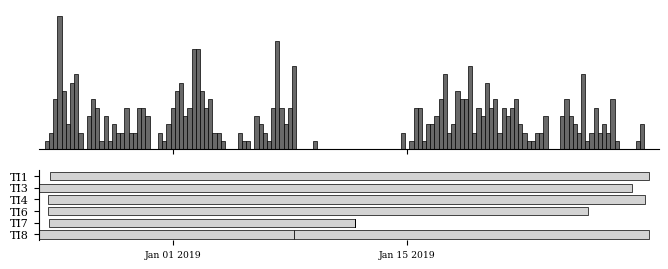

In [79]:
for event_id, row in network_cat.attributes.iterrows():
    time = UTCDateTime(network_cat.events.at[event_id,'ref_time'])
    network_cat.attributes.at[event_id,'time'] = time.matplotlib_date
    network_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
    delta_t = time - t1
    network_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
    network_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:6*60*60]])
stalta_hist, _ = np.histogram(network_cat.attributes['time'],bins=fine_bins)

fig = plt.figure(figsize=(8,3))
gs = fig.add_gridspec(nrows=2,height_ratios=[2,1])
ax = fig.add_subplot(gs[0])

ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),facecolor='dimgray',edgecolor='black',lw=0.5)

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([])
plt.setp(ax.get_xticklabels(), visible=False)

avail_ax = fig.add_subplot(gs[1],sharex=ax)

labels = []
coords = []

for i, code in enumerate(stations):
    subset = df[(df['Station']==code)]
    start = pd.to_datetime(subset['Start'])
    end = pd.to_datetime(subset['End'])
    duration = end - start
        
    avail_ax.barh(-i,duration,height=0.7,left=start,facecolor='lightgrey',edgecolor='black',lw=0.5)
    coords.append(-i)
    labels.append(code)


avail_ax.set_yticks(coords)
avail_ax.set_yticklabels(labels)
avail_ax.spines['right'].set_visible(False)
avail_ax.spines['top'].set_visible(False)
avail_ax.spines['bottom'].set_visible(False)
avail_ax.set_ylim(-5.5,0.5)

avail_ax.set_xlim((fine_bins[0],fine_bins[-1]))
_set_xaxis_obspy_dates(avail_ax)
fig.savefig(os.path.join(p_path,'network_event_timing.eps'),bbox_inches='tight',dpi=400)
fig.savefig(os.path.join(p_path,'network_event_timing.pdf'),bbox_inches='tight',dpi=400)

It can be seen that the seismicity varies throughout the deployment. This could be due to real changes in the behaviour of the seismic source, or changes in noise levels varying the detection rate. For example, the lack of events in the middle of the deployment was found to be due to a storm event (Paul Winberry). 

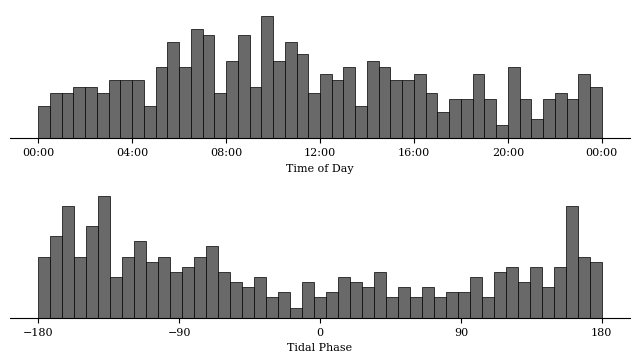

In [80]:
day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(network_cat.attributes['diurnal'],bins=day_bins)

fig, ax = plt.subplots(figsize=(8,4),nrows=2,gridspec_kw={'hspace':0.4})

ax[0].bar(day_bins[:-1],temp_hist,width=np.diff(day_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
ax[0].xaxis.set_major_formatter(myFmt)
ax[0].xaxis.set_major_locator(HourLocator(interval=4))
ax[0].spines['top'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_yticks([])
ax[0].set_xlabel('Time of Day')

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(network_cat.attributes['phase'],bins=tide_bins)

ax[1].bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)

ax[1].spines['top'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_yticks([])
ax[1].set_xlabel('Tidal Phase')
ax[1].set_xticks([-180,-90,0,90,180]);

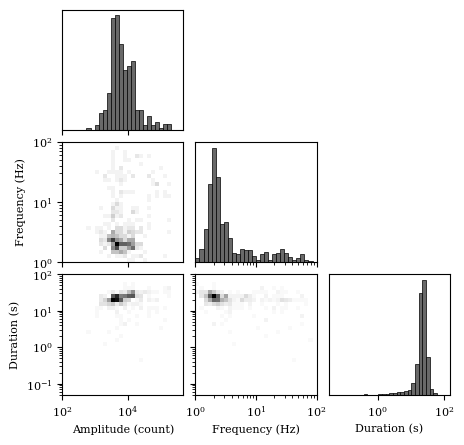

In [81]:
attributes = chunk.load_csv(os.path.join(c_path,'network'),'waveform_attributes')
attributes.dropna(inplace=True)


amps = attributes['amplitude'].to_numpy()
freqs = attributes['mean_freq'].to_numpy()
durs = attributes['duration'].to_numpy()

num_bins = 30

fig = plt.figure(figsize=(5,5))
grid_spec = fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.1,wspace=0.1)

amp_hist = fig.add_subplot(grid_spec[0,0])
freq_hist = fig.add_subplot(grid_spec[1,1])
dur_hist = fig.add_subplot(grid_spec[2,2])

amp_hist.set_xscale('log')
freq_hist.set_xscale('log')
dur_hist.set_xscale('log')

amp_freq = fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
amp_dur = fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
freq_dur = fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

amp_freq.set_xscale('log')
amp_freq.set_yscale('log')
amp_dur.set_xscale('log')
amp_dur.set_yscale('log')
freq_dur.set_yscale('log')
freq_dur.set_xscale('log')

#amp_bins = np.geomspace(np.min(amps),np.max(amps),num_bins+1)
amp_bins = np.geomspace(1e2,5e5,num_bins+1)
freq_bins = np.geomspace(1,100,num_bins+1)
dur_bins = np.geomspace(0.05,100,num_bins+1)

amp_count, _ = np.histogram(amps,bins=amp_bins)
freq_count, _ = np.histogram(freqs,bins=freq_bins)
dur_count, _ = np.histogram(durs,bins=dur_bins)

amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
freq_hist.set_yticks([])

amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
amp_hist.set_yticks([])

dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
dur_hist.set_yticks([])

amp_dur.set_ylim(dur_hist.get_xlim())
freq_dur.set_ylim(dur_hist.get_xlim())


amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

amp_ylim = amp_hist.get_ylim()
amp_hist.set_ylim(amp_ylim)

freq_ylim = freq_hist.get_ylim()
freq_hist.set_ylim(freq_ylim)

dur_ylim = dur_hist.get_ylim()
dur_hist.set_ylim(dur_ylim)

amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
freq_dur.set_ylim(dur_bins[0],dur_bins[-1])


plt.setp(freq_hist.get_xticklabels(), visible=False)
plt.setp(amp_hist.get_xticklabels(), visible=False)
plt.setp(amp_freq.get_xticklabels(), visible=False)
plt.setp(freq_dur.get_yticklabels(), visible=False)

amp_freq.set_ylabel('Frequency (Hz)')
amp_dur.set_ylabel('Duration (s)')
amp_dur.set_xlabel('Amplitude (count)')
freq_dur.set_xlabel('Frequency (Hz)')
dur_hist.set_xlabel('Duration (s)')

fig.savefig(os.path.join(p_path,'network_catalogue_attributes.eps'),bbox_inches='tight',dpi=400)
fig.savefig(os.path.join(p_path,'network_catalogue_attributes.pdf'),bbox_inches='tight',dpi=400)

### Triplet Catalogues

The triplet catalogues were also produced using the multi-STA/LTA algorithm with two of the three stations requiring a trigger for the event to be detected. The 'B' and 'C' stations were only functional for part of the season, so these catalogues only contain events for these periods.

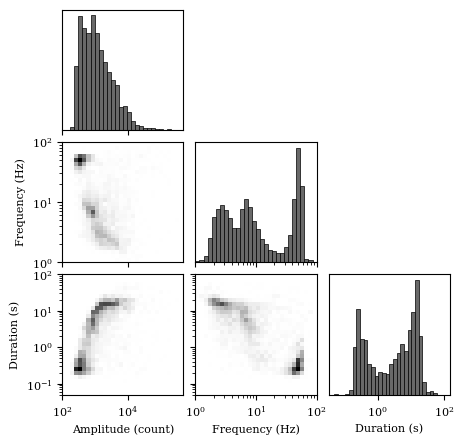

In [82]:
attributes3 = chunk.load_csv(os.path.join(c_path,'TI3'),'waveform_attributes')
attributes6 = chunk.load_csv(os.path.join(c_path,'TI6'),'waveform_attributes')
attributes8 = chunk.load_csv(os.path.join(c_path,'TI8'),'waveform_attributes')

attributes = pd.concat([attributes3,attributes6,attributes8])
attributes.dropna(inplace=True)


amps = attributes['amplitude'].to_numpy()
freqs = attributes['mean_freq'].to_numpy()
durs = attributes['duration'].to_numpy()

num_bins = 30

fig = plt.figure(figsize=(5,5))
grid_spec = fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.1,wspace=0.1)

amp_hist = fig.add_subplot(grid_spec[0,0])
freq_hist = fig.add_subplot(grid_spec[1,1])
dur_hist = fig.add_subplot(grid_spec[2,2])

amp_hist.set_xscale('log')
freq_hist.set_xscale('log')
dur_hist.set_xscale('log')

amp_freq = fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
amp_dur = fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
freq_dur = fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

amp_freq.set_xscale('log')
amp_freq.set_yscale('log')
amp_dur.set_xscale('log')
amp_dur.set_yscale('log')
freq_dur.set_yscale('log')
freq_dur.set_xscale('log')

amp_bins = np.geomspace(1e2,5e5,num_bins+1)
freq_bins = np.geomspace(1,100,num_bins+1)
dur_bins = np.geomspace(0.05,100,num_bins+1)

amp_count, _ = np.histogram(amps,bins=amp_bins)
freq_count, _ = np.histogram(freqs,bins=freq_bins)
dur_count, _ = np.histogram(durs,bins=dur_bins)

amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
freq_hist.set_yticks([])

amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
amp_hist.set_yticks([])

dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
dur_hist.set_yticks([])

amp_dur.set_ylim(dur_hist.get_xlim())
freq_dur.set_ylim(dur_hist.get_xlim())


amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

amp_ylim = amp_hist.get_ylim()
amp_hist.set_ylim(amp_ylim)

freq_ylim = freq_hist.get_ylim()
freq_hist.set_ylim(freq_ylim)

dur_ylim = dur_hist.get_ylim()
dur_hist.set_ylim(dur_ylim)

amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
freq_dur.set_ylim(dur_bins[0],dur_bins[-1])


plt.setp(freq_hist.get_xticklabels(), visible=False)
plt.setp(amp_hist.get_xticklabels(), visible=False)
plt.setp(amp_freq.get_xticklabels(), visible=False)
plt.setp(freq_dur.get_yticklabels(), visible=False)

amp_freq.set_ylabel('Frequency (Hz)')
amp_dur.set_ylabel('Duration (s)')
amp_dur.set_xlabel('Amplitude (count)')
freq_dur.set_xlabel('Frequency (Hz)')
dur_hist.set_xlabel('Duration (s)')

fig.savefig(os.path.join(p_path,'triplet_catalogue_attributes.eps'),bbox_inches='tight',dpi=400)
fig.savefig(os.path.join(p_path,'triplet_catalogue_attributes.pdf'),bbox_inches='tight',dpi=400)

### Single Station Catalogues

Along with the triplet catalogues, event detection at each individual instrument can provide an indication on the local sesimicity with many small events not registering on multiple seismometers.

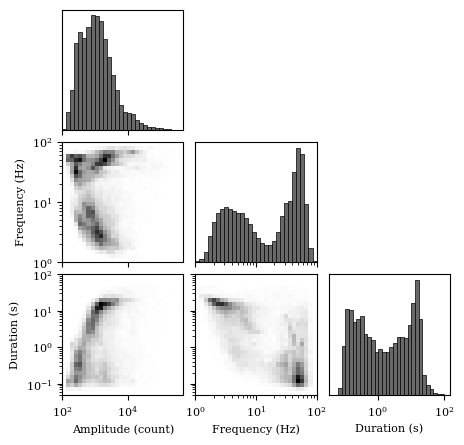

In [83]:
attribute_lst = []

for net in inv:
    for sta in net:
        attribute_lst.append(chunk.load_csv(os.path.join(c_path,sta.code + '_single'),'waveform_attributes'))

attributes = pd.concat(attribute_lst)
attributes.dropna(inplace=True)

amps = attributes['amplitude'].to_numpy()
freqs = attributes['mean_freq'].to_numpy()
durs = attributes['duration'].to_numpy()

num_bins = 30

fig = plt.figure(figsize=(5,5))
grid_spec = fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.1,wspace=0.1)

amp_hist = fig.add_subplot(grid_spec[0,0])
freq_hist = fig.add_subplot(grid_spec[1,1])
dur_hist = fig.add_subplot(grid_spec[2,2])

amp_hist.set_xscale('log')
freq_hist.set_xscale('log')
dur_hist.set_xscale('log')

amp_freq = fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
amp_dur = fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
freq_dur = fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

amp_freq.set_xscale('log')
amp_freq.set_yscale('log')
amp_dur.set_xscale('log')
amp_dur.set_yscale('log')
freq_dur.set_yscale('log')
freq_dur.set_xscale('log')

amp_bins = np.geomspace(1e2,5e5,num_bins+1)
freq_bins = np.geomspace(1,100,num_bins+1)
dur_bins = np.geomspace(0.05,100,num_bins+1)

amp_count, _ = np.histogram(amps,bins=amp_bins)
freq_count, _ = np.histogram(freqs,bins=freq_bins)
dur_count, _ = np.histogram(durs,bins=dur_bins)

amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
freq_hist.set_yticks([])

amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
amp_hist.set_yticks([])

dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
dur_hist.set_yticks([])

amp_dur.set_ylim(dur_hist.get_xlim())
freq_dur.set_ylim(dur_hist.get_xlim())


amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

amp_ylim = amp_hist.get_ylim()
amp_hist.set_ylim(amp_ylim)

freq_ylim = freq_hist.get_ylim()
freq_hist.set_ylim(freq_ylim)

dur_ylim = dur_hist.get_ylim()
dur_hist.set_ylim(dur_ylim)

amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
freq_dur.set_ylim(dur_bins[0],dur_bins[-1])


plt.setp(freq_hist.get_xticklabels(), visible=False)
plt.setp(amp_hist.get_xticklabels(), visible=False)
plt.setp(amp_freq.get_xticklabels(), visible=False)
plt.setp(freq_dur.get_yticklabels(), visible=False)

amp_freq.set_ylabel('Frequency (Hz)')
amp_dur.set_ylabel('Duration (s)')
amp_dur.set_xlabel('Amplitude (count)')
freq_dur.set_xlabel('Frequency (Hz)')
dur_hist.set_xlabel('Duration (s)')

fig.savefig(os.path.join(p_path,'single_catalogue_attributes.pdf'),bbox_inches='tight',dpi=400)

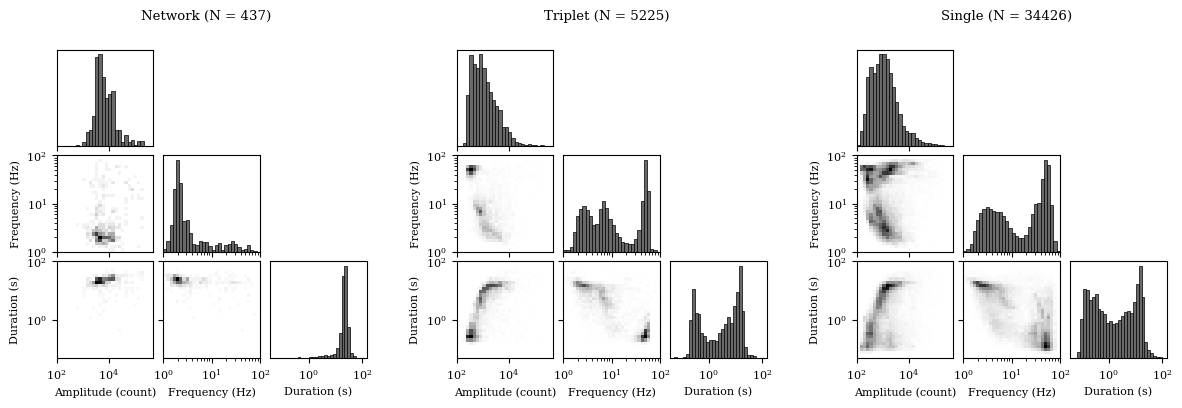

In [84]:
master_fig = plt.figure(figsize=(12,4))
subfigs = master_fig.subfigures(ncols=3)

titles = ['Network','Triplet','Single']


amp_bins = np.geomspace(1e2,5e5,num_bins+1)
freq_bins = np.geomspace(1,100,num_bins+1)
dur_bins = np.geomspace(0.05,100,num_bins+1)

network_attributes = chunk.load_csv(os.path.join(c_path,'network'),'waveform_attributes')
network_attributes.dropna(inplace=True)

attributes3 = chunk.load_csv(os.path.join(c_path,'TI3'),'waveform_attributes')
attributes6 = chunk.load_csv(os.path.join(c_path,'TI6'),'waveform_attributes')
attributes8 = chunk.load_csv(os.path.join(c_path,'TI8'),'waveform_attributes')

triplet_attributes = pd.concat([attributes3,attributes6,attributes8])
triplet_attributes.dropna(inplace=True)

attribute_lst = []

for net in inv:
    for sta in net:
        attribute_lst.append(chunk.load_csv(os.path.join(c_path,sta.code + '_single'),'waveform_attributes'))

single_attributes = pd.concat(attribute_lst)
single_attributes.dropna(inplace=True)

all_attributes = [network_attributes,triplet_attributes,single_attributes]

for i, fig in enumerate(subfigs):
    grid_spec = fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.1,wspace=0.1)

    amp_hist = fig.add_subplot(grid_spec[0,0])
    freq_hist = fig.add_subplot(grid_spec[1,1])
    dur_hist = fig.add_subplot(grid_spec[2,2])

    amp_hist.set_xscale('log')
    freq_hist.set_xscale('log')
    dur_hist.set_xscale('log')

    amp_freq = fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
    amp_dur = fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
    freq_dur = fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

    amp_freq.set_xscale('log')
    amp_freq.set_yscale('log')
    amp_dur.set_xscale('log')
    amp_dur.set_yscale('log')
    freq_dur.set_yscale('log')
    freq_dur.set_xscale('log')

    attributes = all_attributes[i]

    amps = attributes['amplitude'].to_numpy()
    freqs = attributes['mean_freq'].to_numpy()
    durs = attributes['duration'].to_numpy()

    amp_count, _ = np.histogram(amps,bins=amp_bins)
    freq_count, _ = np.histogram(freqs,bins=freq_bins)
    dur_count, _ = np.histogram(durs,bins=dur_bins)

    amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
    amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
    freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

    freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
    freq_hist.set_yticks([])

    amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
    amp_hist.set_yticks([])

    dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)
    dur_hist.set_yticks([])

    amp_dur.set_ylim(dur_hist.get_xlim())
    freq_dur.set_ylim(dur_hist.get_xlim())


    amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
    amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
    freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

    amp_ylim = amp_hist.get_ylim()
    amp_hist.set_ylim(amp_ylim)

    freq_ylim = freq_hist.get_ylim()
    freq_hist.set_ylim(freq_ylim)

    dur_ylim = dur_hist.get_ylim()
    dur_hist.set_ylim(dur_ylim)
 
    amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
    amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

    amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
    amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

    freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
    freq_dur.set_ylim(dur_bins[0],dur_bins[-1])

    plt.setp(freq_hist.get_xticklabels(), visible=False)
    plt.setp(amp_hist.get_xticklabels(), visible=False)
    plt.setp(amp_freq.get_xticklabels(), visible=False)
    plt.setp(freq_dur.get_yticklabels(), visible=False)

    amp_freq.set_ylabel('Frequency (Hz)')
    amp_dur.set_ylabel('Duration (s)')
    amp_dur.set_xlabel('Amplitude (count)')
    freq_dur.set_xlabel('Frequency (Hz)')
    dur_hist.set_xlabel('Duration (s)')

    fig.suptitle(titles[i] + ' (N = ' + str(len(attributes)) + ')')

master_fig.savefig(os.path.join(p_path,'all_catalogue_attributes.pdf'),bbox_inches='tight',dpi=400)


Note that there are many more events in the single catalogues than the triplet as (a) this is the sum of all catalogues (there are more single catalogues than triplets) and (b) the triplet stations were only operating for part of the season. A notable feature of the triplet and single station catalogues are the bimodal distributions in central frequency. This has previously been interpreted as being due to surface and basal events. In this case, we have lower frequency basal events from stick-slip motion, this this may instead represent different scales of events with large low frequency events and small high frequency events. It is still notable however that this occurs in two clusters rather than a continuous spectrum of frequencies. A distinguishing factor would therefore be to consider how strong the Rayleigh correlation is in the events to determine if many of the low frequency events are actually local surface crevassing in the single station catalogues rather than the large stick-slip motions. There must be at least some local events producing low frequency signals as there are many more events in this frequency band detected at the single stations compared to those that register across the network. That is, there are probably many low amplitude, low frequency events.

In [85]:
#diurnal and tidal wrapping of the single station catalogues - do the small events have environmental drivers as well as the large?
temporal_attributes = []

for net in inv:
    for sta in net:
        single_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,sta.code + '_single'))
        for event_id, row in single_cat.attributes.iterrows():
            time = UTCDateTime(single_cat.events.at[event_id,'ref_time'])
            single_cat.attributes.at[event_id,'time'] = time.matplotlib_date
            single_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
            delta_t = time - t1
            single_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)

            temporal_attributes.append(single_cat.attributes)

all_temporal_atts = pd.concat(temporal_attributes)
all_temporal_atts.dropna(inplace=True)

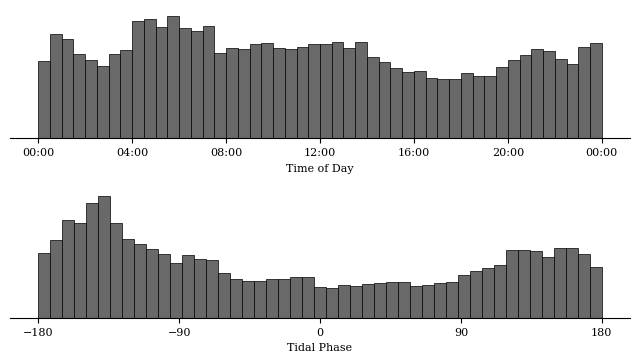

In [86]:
day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(all_temporal_atts['diurnal'],bins=day_bins)

fig, ax = plt.subplots(figsize=(8,4),nrows=2,gridspec_kw={'hspace':0.4})

ax[0].bar(day_bins[:-1],temp_hist,width=np.diff(day_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
ax[0].xaxis.set_major_formatter(myFmt)
ax[0].xaxis.set_major_locator(HourLocator(interval=4))
ax[0].spines['top'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_yticks([])
ax[0].set_xlabel('Time of Day')

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(all_temporal_atts['phase'],bins=tide_bins)

ax[1].bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)

ax[1].spines['top'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_yticks([])
ax[1].set_xlabel('Tidal Phase')
ax[1].set_xticks([-180,-90,0,90,180]);

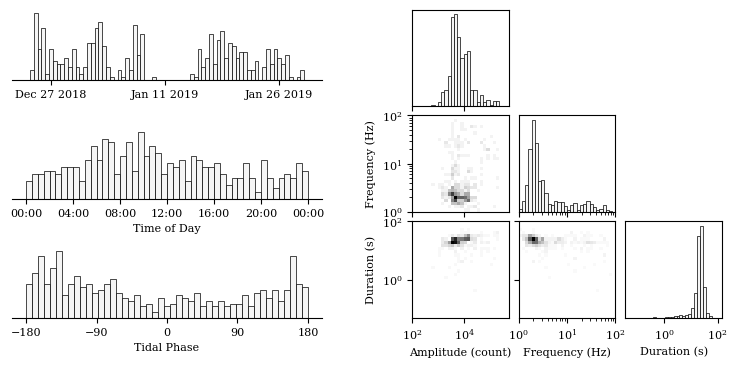

In [87]:
#plot of network catalogue detection times, dirunal trend, and tidal trend on left, and event attribute corner plot on right. Just combining all the above information...

master_fig = plt.figure(figsize=(8,4))
dist_fig, att_fig = master_fig.subfigures(ncols=2)

dist_gs = dist_fig.add_gridspec(nrows=3,hspace=0.7)

det_ax = dist_fig.add_subplot(dist_gs[0])
diurnal_ax = dist_fig.add_subplot(dist_gs[1])
tide_ax = dist_fig.add_subplot(dist_gs[2])

fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:12*60*60]])
stalta_hist, _ = np.histogram(network_cat.attributes['time'],bins=fine_bins)


det_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),facecolor='whitesmoke',edgecolor='black',lw=0.5)

det_ax.spines['top'].set_visible(False)
det_ax.spines['left'].set_visible(False)
det_ax.spines['right'].set_visible(False)
det_ax.set_yticks([])

myFmt = DateFormatter("%b %d %Y",usetex=False)
det_ax.xaxis.set_major_formatter(myFmt)
det_ax.xaxis.set_major_locator(DayLocator(interval=15))


day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(network_cat.attributes['diurnal'],bins=day_bins)

diurnal_ax.bar(day_bins[:-1],temp_hist,width=np.diff(day_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
diurnal_ax.xaxis.set_major_formatter(myFmt)
diurnal_ax.xaxis.set_major_locator(HourLocator(interval=4))
diurnal_ax.spines['top'].set_visible(False)
diurnal_ax.spines['left'].set_visible(False)
diurnal_ax.spines['right'].set_visible(False)
diurnal_ax.set_yticks([])
diurnal_ax.set_xlabel('Time of Day')

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(network_cat.attributes['phase'],bins=tide_bins)

tide_ax.bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)

tide_ax.spines['top'].set_visible(False)
tide_ax.spines['left'].set_visible(False)
tide_ax.spines['right'].set_visible(False)
tide_ax.set_yticks([])
tide_ax.set_xlabel('Tidal Phase')
tide_ax.set_xticks([-180,-90,0,90,180]);


#ATTRIBUTES SUBFIGURE
grid_spec = att_fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.1,wspace=0.1)

amp_hist = att_fig.add_subplot(grid_spec[0,0])
freq_hist = att_fig.add_subplot(grid_spec[1,1])
dur_hist = att_fig.add_subplot(grid_spec[2,2])

amp_hist.set_xscale('log')
freq_hist.set_xscale('log')
dur_hist.set_xscale('log')

amp_freq = att_fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
amp_dur = att_fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
freq_dur = att_fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

amp_freq.set_xscale('log')
amp_freq.set_yscale('log')
amp_dur.set_xscale('log')
amp_dur.set_yscale('log')
freq_dur.set_yscale('log')
freq_dur.set_xscale('log')


amps = network_attributes['amplitude'].to_numpy()
freqs = network_attributes['mean_freq'].to_numpy()
durs = network_attributes['duration'].to_numpy()

amp_count, _ = np.histogram(amps,bins=amp_bins)
freq_count, _ = np.histogram(freqs,bins=freq_bins)
dur_count, _ = np.histogram(durs,bins=dur_bins)

amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
freq_hist.set_yticks([])

amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
amp_hist.set_yticks([])

dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
dur_hist.set_yticks([])

amp_dur.set_ylim(dur_hist.get_xlim())
freq_dur.set_ylim(dur_hist.get_xlim())


amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

amp_ylim = amp_hist.get_ylim()
amp_hist.set_ylim(amp_ylim)

freq_ylim = freq_hist.get_ylim()
freq_hist.set_ylim(freq_ylim)

dur_ylim = dur_hist.get_ylim()
dur_hist.set_ylim(dur_ylim)

amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
freq_dur.set_ylim(dur_bins[0],dur_bins[-1])

plt.setp(freq_hist.get_xticklabels(), visible=False)
plt.setp(amp_hist.get_xticklabels(), visible=False)
plt.setp(amp_freq.get_xticklabels(), visible=False)
plt.setp(freq_dur.get_yticklabels(), visible=False)

amp_freq.set_ylabel('Frequency (Hz)')
amp_dur.set_ylabel('Duration (s)')
amp_dur.set_xlabel('Amplitude (count)')
freq_dur.set_xlabel('Frequency (Hz)')
dur_hist.set_xlabel('Duration (s)')

master_fig.savefig(os.path.join(cloud_path,'FigS1_network_catalogue.pdf'),bbox_inches='tight')

There is a much stronger tidal trend than diurnal, with more events occuring as the tide begins to rise (0 is low tide for Hilbert transform method of instantaneous phase).

## Repeating Icequakes

Visual inspection of the event catalogue indicates that there a repeating icequakes occuring at this site, likely due to a repeated stick-slip mechanism. Due to the similarity of these events, cross-correlation and template matching techniques can be applied to form repeating event groups.

To select template events that well represent the catalogue, the following steps were taken:

1) a cross-correlation matrix for the full network catalogue was produced.
2) these cross-correlation values were used to perform hierachial clustering of the event catalogue
3) cluster cuts were made at a threshold of [NUM] to form [NUM] clusters
4) as many of these clusters were single events that did not match, only clusters of 3 or more events were used to form event groups
5) within the selected clusters, the event with the highest mean cross-correlation with other events in that cluster was taken as the centroid event and used as a template
6) these centroid templates were used with a correlation detector to form a new event catalogue of repeating events

As this repeating event catalogue was detected with a correlation trigger, these events are aligned and well suited for stacking.


In [88]:
#these now can be arranged into clusters...
clusters_file = np.load(os.path.join(c_path,'network','clusters_N.npz'))
clusters = clusters_file['clusters']

cc_file = np.load(os.path.join(c_path,'network','cc_matrix_N.npz'))
cc_mat = cc_file['cc_mat']

unique = pd.value_counts(clusters)
clust_ind = unique[unique>3] #if 3 or more events in cluster, get template 

templates = {}
template_loc = {}

for i, clust_N in enumerate(clust_ind):
    clust_id = clust_ind.index[i] #numerical label of cluster

    cc_ind = np.where(clusters==clust_id)[0] #indices in the cc matrix belonging to this cluster
    temp = cc_mat[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = network_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_id)] = central_id
    template_loc[str(clust_id)] = network_cat.events.index.get_loc(central_id)

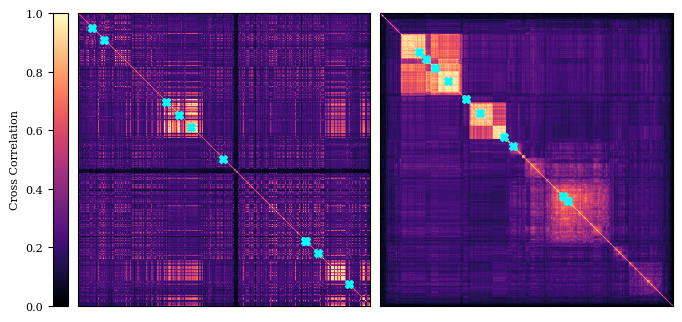

In [89]:
ind = np.argsort(clusters)

temp = cc_mat[ind,:]
cc_sort = temp[:,ind]

sort_temps = {}
for temp_id, temp_loc in template_loc.items():
    sort_temps[temp_id] = np.argwhere(ind==temp_loc)[0][0]

event_pos = {}
for clust_id, event_id in templates.items():
    event_pos[event_id] = sort_temps[clust_id]

fig = plt.figure(figsize=(8,3.8))
gs = fig.add_gridspec(nrows=len(template_loc),ncols=3,width_ratios=[0.05,1,1],hspace=0,wspace=0.05)

cb_ax = fig.add_subplot(gs[:,0])
chron_ax = fig.add_subplot(gs[:,1])
sort_ax = fig.add_subplot(gs[:,2])

cc_plot = chron_ax.imshow(cc_mat,cmap='magma',vmin=0,vmax=1)
chron_ax.set_xticks([])
chron_ax.set_yticks([])

cc_plot = sort_ax.imshow(cc_sort,cmap='magma',vmin=0,vmax=1)
sort_ax.set_xticks([])
sort_ax.set_yticks([])

plt.colorbar(cc_plot,cax=cb_ax,label='Cross Correlation')
cb_ax.yaxis.set_ticks_position('left')
cb_ax.yaxis.set_label_position('left')
cb_ax.set_ylim(0,1)

i = 0
for clust_id, loc in template_loc.items():
    chron_ax.plot(loc,loc,marker='X',color='cyan')
    if i % 2 == 0:
        va = 'top'
    else:
        va = 'bottom'
    i += 1

for event_id, loc in event_pos.items():
    sort_ax.plot(loc,loc,marker='X',color='cyan')

fig.savefig(os.path.join(p_path,'cross_correlation_summary.pdf'),bbox_inches='tight')

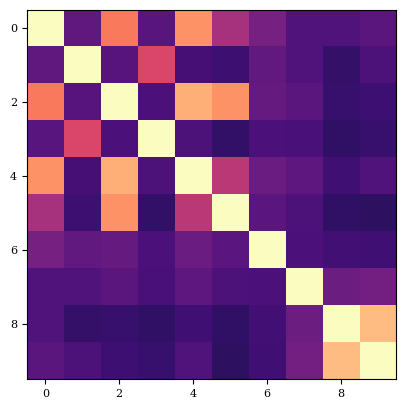

In [90]:
#dendrograms of the chosen template events, relation between clusters
ind = np.array([i for i in event_pos.values()]) #will want to sort this A-J and label these on the axes
temp = cc_sort[ind,:]
cc_temp = temp[:,ind]

plt.imshow(cc_temp,cmap='magma',vmin=0,vmax=1)

#can convert the cross-correlation to a similarity matrix and do the dendrogram for this...

In [91]:
from scipy.cluster import hierarchy
from scipy.spatial import distance

dissimilarity = 1-cc_temp
dissimilarity = distance.squareform(dissimilarity)
threshold = 0.2

linkage = hierarchy.linkage(dissimilarity, method="average",optimal_ordering=True)
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

In [92]:
templates

{'31': '20190125T125311Z',
 '43': '20190120T053611Z',
 '34': '20190102T113721Z',
 '44': '20181226T031945Z',
 '33': '20190101T192748Z',
 '32': '20190102T230808Z',
 '39': '20190107T105233Z',
 '54': '20181225T105137Z',
 '116': '20190121T065802Z',
 '117': '20190120T064117Z'}

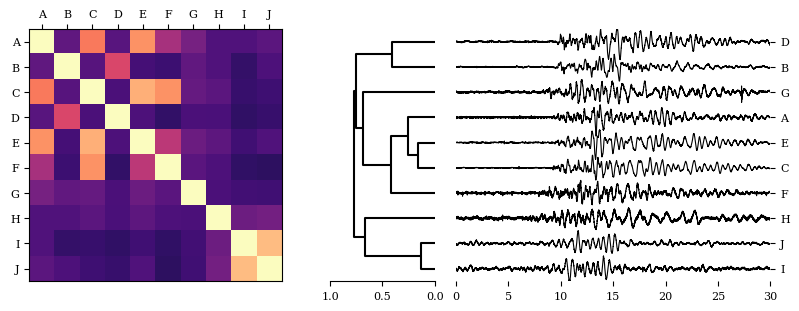

In [93]:
fig, [cc_ax,dend_ax,waveform_ax] = plt.subplots(ncols=3,figsize=(8,3),gridspec_kw={'width_ratios':[3,1,3],'wspace':0},layout='constrained')
labels = ['A','B','C','D','E','F','G','H','I','J']
temp_labels = {num:labels[i] for i,num in enumerate(sort_temps.keys())}
cluster_nums = [key for key in templates.keys()]

cc_ax.imshow(cc_temp,cmap='magma',vmin=0,vmax=1)
cc_ax.set_xticks(np.arange(len(labels)),labels=labels)
cc_ax.set_yticks(np.arange(len(labels)),labels=labels)

cc_ax.xaxis.set_ticks_position('top')

dend_ax.spines['top'].set_visible(False)
#dend_ax.spines['bottom'].set_visible(False)
dend_ax.spines['left'].set_visible(False)
dend_ax.spines['right'].set_visible(False)



waveform_ax.spines['top'].set_visible(False)
waveform_ax.spines['bottom'].set_visible(False)
waveform_ax.spines['left'].set_visible(False)
waveform_ax.spines['right'].set_visible(False)

hierarchy.set_link_color_palette(['darkgreen','darkred','slategrey','peru','deeppink','olive'])

#dend_ax.vlines(threshold,ymin=0,ymax=10*len(event_list),color='grey',ls='--',lw=0.8)

dendrogram = hierarchy.dendrogram(linkage,color_threshold=0,orientation='left',ax=dend_ax,labels=cluster_nums,no_labels=True,above_threshold_color='black')

dend_ax.set_xlim(1,0)

old_index = None
station_names = []
for i, cluster_num in enumerate(dendrogram['ivl']):
    template_id = templates[cluster_num]
    offset = 5 + i * 10

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=10,length=25)
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    stream = temp_event.get_data_window()
    tr = stream.select(station='TI3A',channel='CHZ')[0]

    waveform_ax.plot(tr.times(),tr.data/tr.data.max()*5 + offset,lw=0.8,color='black')
    waveform_ax.set_xlim(0,30)

sorted_y_labels = [temp_labels[key] for key in dendrogram['ivl']]

waveform_ax.set_ylim((0,clusters.size*10))
waveform_ax.set_yticks(np.arange(0,clusters.size*10,10)+5)
#waveform_ax.set_yticklabels(station_names)
waveform_ax.set_yticklabels(sorted_y_labels)
waveform_ax.yaxis.set_ticks_position('right')

fig.savefig(os.path.join(p_path,'template_dendrogram.pdf'),bbox_inches='tight')

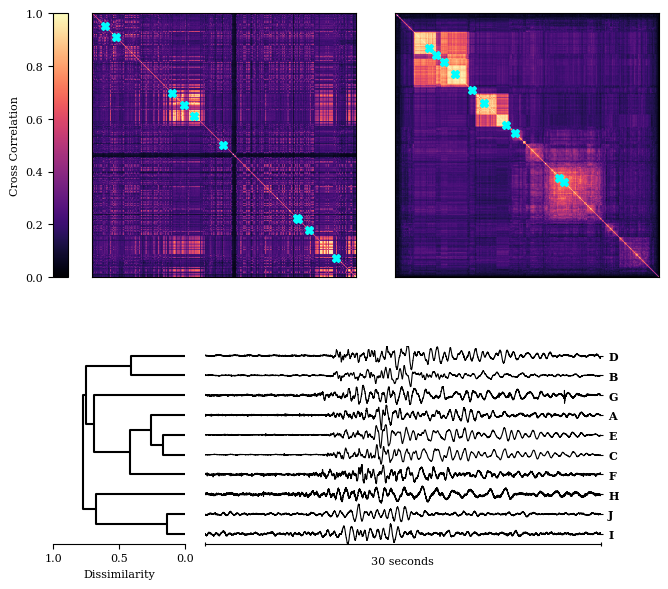

In [94]:
#supplementary figure showing the cross-correlation matrix and template dendrograms - shows which event groups are more similar to each other...

master_fig = plt.figure(figsize=(8,6))

xcorr_fig, dendro_fig = master_fig.subfigures(nrows=2,height_ratios=(2,1.5),hspace=0)

gs = xcorr_fig.add_gridspec(nrows=len(template_loc),ncols=3,width_ratios=[0.05,1,1],hspace=0,wspace=0.05)

cb_ax = xcorr_fig.add_subplot(gs[:,0])
chron_ax = xcorr_fig.add_subplot(gs[:,1])
sort_ax = xcorr_fig.add_subplot(gs[:,2])

cc_plot = chron_ax.imshow(cc_mat,cmap='magma',vmin=0,vmax=1)
chron_ax.set_xticks([])
chron_ax.set_yticks([])

cc_plot = sort_ax.imshow(cc_sort,cmap='magma',vmin=0,vmax=1)
sort_ax.set_xticks([])
sort_ax.set_yticks([])

plt.colorbar(cc_plot,cax=cb_ax,label='Cross Correlation')
cb_ax.yaxis.set_ticks_position('left')
cb_ax.yaxis.set_label_position('left')
cb_ax.set_ylim(0,1)

i = 0
for clust_id, loc in template_loc.items():
    chron_ax.plot(loc,loc,marker='X',color='cyan')
    if i % 2 == 0:
        va = 'top'
    else:
        va = 'bottom'
    i += 1

for event_id, loc in event_pos.items():
    sort_ax.plot(loc,loc,marker='X',color='cyan')


dendro_gs = dendro_fig.add_gridspec(ncols=3,width_ratios = [1,3,0.4],wspace=0.1)
dend_ax = dendro_fig.add_subplot(dendro_gs[0])
waveform_ax = dendro_fig.add_subplot(dendro_gs[1])

labels = ['A','B','C','D','E','F','G','H','I','J']
temp_labels = {num:labels[i] for i,num in enumerate(sort_temps.keys())}
cluster_nums = [key for key in templates.keys()]


dend_ax.spines['top'].set_visible(False)
#dend_ax.spines['bottom'].set_visible(False)
dend_ax.spines['left'].set_visible(False)
dend_ax.spines['right'].set_visible(False)



waveform_ax.spines['top'].set_visible(False)
#waveform_ax.spines['bottom'].set_visible(False)
waveform_ax.spines['left'].set_visible(False)
waveform_ax.spines['right'].set_visible(False)

hierarchy.set_link_color_palette(['darkgreen','darkred','slategrey','peru','deeppink','olive'])

#dend_ax.vlines(threshold,ymin=0,ymax=10*len(event_list),color='grey',ls='--',lw=0.8)

dendrogram = hierarchy.dendrogram(linkage,color_threshold=0,orientation='left',ax=dend_ax,labels=cluster_nums,no_labels=True,above_threshold_color='black')

dend_ax.set_xlim(1,0)
dend_ax.set_xlabel('Dissimilarity')

old_index = None
station_names = []
for i, cluster_num in enumerate(dendrogram['ivl']):
    template_id = templates[cluster_num]
    offset = 5 + i * 10

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=10,length=25)
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    stream = temp_event.get_data_window()
    tr = stream.select(station='TI3A',channel='CHZ')[0]

    waveform_ax.plot(tr.times(),tr.data/tr.data.max()*5 + offset,lw=0.8,color='black')
    waveform_ax.set_xlim(0,30)

sorted_y_labels = [temp_labels[key] for key in dendrogram['ivl']]

waveform_ax.set_ylim((0,clusters.size*10))
waveform_ax.set_yticks(np.arange(0,clusters.size*10,10)+5)
#waveform_ax.set_yticklabels(station_names)
waveform_ax.set_yticklabels(sorted_y_labels,weight='bold')
waveform_ax.yaxis.set_ticks_position('right')

waveform_ax.set_xticks([0,30])
waveform_ax.set_xticklabels(['',''])
waveform_ax.tick_params(direction='inout')
waveform_ax.set_xlabel('30 seconds')

master_fig.savefig(os.path.join(cloud_path,'FigS2_template_selection.pdf'),bbox_inches='tight')

In [95]:
temp_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network','filtered'),templates=True)
groups = temp_cat.group_split()
print('Template Matched Events:',temp_cat.N)

Template Matched Events: 1135


In [96]:
for event_id, row in temp_cat.attributes.iterrows():
    time = UTCDateTime(temp_cat.events.at[event_id,'ref_time'])
    temp_cat.attributes.at[event_id,'time'] = time.matplotlib_date
    temp_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
    delta_t = time - t1
    temp_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
    temp_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

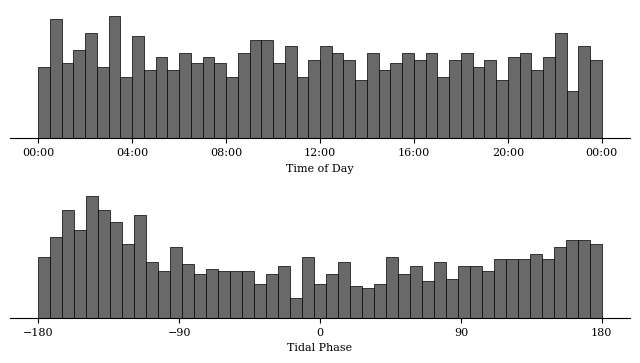

In [97]:
day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(temp_cat.attributes['diurnal'],bins=day_bins)

fig, ax = plt.subplots(figsize=(8,4),nrows=2,gridspec_kw={'hspace':0.4})

ax[0].bar(day_bins[:-1],temp_hist,width=np.diff(day_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
ax[0].xaxis.set_major_formatter(myFmt)
ax[0].xaxis.set_major_locator(HourLocator(interval=4))
ax[0].spines['top'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_yticks([])
ax[0].set_xlabel('Time of Day')

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(temp_cat.attributes['phase'],bins=tide_bins)

ax[1].bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='dimgray',edgecolor='black',lw=0.5)

ax[1].spines['top'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_yticks([])
ax[1].set_xlabel('Tidal Phase')
ax[1].set_xticks([-180,-90,0,90,180]);


In [98]:
stacked_streams = {}
for cluster_num in groups.keys():
    stream = read(os.path.join(path,'stacked_waveforms','filtered_stacked_waveforms_cluster_'+str(cluster_num) + '.mseed'))
    #stream = stream.select(station='TI?A')
    #stream = stream.filter("bandpass",freqmin=1,freqmax=10)
    #for tr in stream:
    #    tr.stats.starttime = UTCDateTime(2019,1,10)
    #    tr.remove_response(inv,output='DISP')

    stacked_streams[cluster_num] = stream

We can now load the waveforms for the events in this template catalogue for stacking and further analysis.

In [99]:
ss_temps = dict(sort_temps)
ss_temps.pop('116')
ss_temps.pop('117')

279

/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_94127/3816821359.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_cat.attributes.at[event_id,'time'] = time.matplotlib_date
/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_94127/3816821359.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_94127/3816821

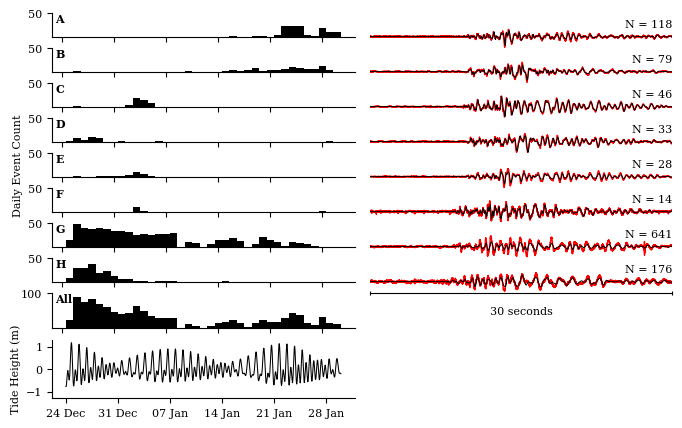

In [100]:
N_clust = len(ss_temps)
labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O']
temp_labels = {num:labels[i] for i,num in enumerate(ss_temps.keys())}

fig = plt.figure(figsize=(8,5))
gs = fig.add_gridspec(nrows=3*(N_clust+3),ncols=2,wspace=0.05,hspace=0.0)

all_hist = []
all_tr = []

i = 0
for clust_num, pos in ss_temps.items():

    hist_ax = fig.add_subplot(gs[3*i:3*i+2,0])
    tr_ax = fig.add_subplot(gs[3*i+1:3*i+3,1])

    all_hist.append(hist_ax)
    all_tr.append(tr_ax)

    group_cat = groups[int(clust_num)]
    for event_id, row in group_cat.attributes.iterrows():
        time = UTCDateTime(group_cat.events.at[event_id,'ref_time'])
        group_cat.attributes.at[event_id,'time'] = time.matplotlib_date
        group_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
        delta_t = time - t1
        group_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
        group_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

    fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:24*60*60]])
    stalta_hist, _ = np.histogram(group_cat.attributes['time'],bins=fine_bins)

    hist_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
    hist_ax.spines['top'].set_visible(False)
    #hist_ax.spines['left'].set_visible(False)
    hist_ax.spines['right'].set_visible(False)

    myFmt = DateFormatter("%d %b")
    hist_ax.xaxis.set_major_formatter(myFmt)
    hist_ax.xaxis.set_major_locator(DayLocator(interval=7))
    #if i != N_clust-1:
    plt.setp(hist_ax.get_xticklabels(), visible=False)

    if i == 4:
        hist_ax.set_ylabel('Daily Event Count')

    stream = stacked_streams[int(clust_num)]

    template_id = templates[str(clust_num)]

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=10,length=25)
    
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    t = stream.select(station='TI3A',component='Z')[0].times()

    tr_ax.plot(t,temp_event.get_data_window()[0].data,lw=1,color='red')
    tr_ax.plot(t,stream.select(station='TI3A',component='Z')[0].data,lw=0.7,c='k')    
    tr_ax.set_xlim(0,30)
    

    if i != N_clust-1:
        tr_ax.set_axis_off()



    else:
        tr_ax.spines['top'].set_visible(False)
        tr_ax.spines['left'].set_visible(False)
        tr_ax.spines['right'].set_visible(False)

        tr_ax.set_xticks([0,30])
        tr_ax.set_yticks([])
        tr_ax.set_xticklabels(['',''])
        tr_ax.tick_params(direction='inout')
        tr_ax.set_xlabel('30 seconds')

    N_group = groups[int(clust_num)].N

    tr_ax.annotate('N = ' + str(N_group),(1,1.25),xycoords='axes fraction',ha='right',va='top')
    hist_ax.annotate(temp_labels[clust_num],(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')
    i += 1

max_lim_hist = np.max(np.array([all_hist[i].get_ylim()[1] for i in range(N_clust)]))
max_lim_tr = np.max(np.array([np.max(np.abs(all_tr[i].get_ylim())) for i in range(N_clust)]))

for i in range(N_clust):
    all_hist[i].set_ylim(0,max_lim_hist)
    all_hist[i].set_yticks([50])

    max_y = np.max(np.abs(all_tr[i].get_ylim()))
    #all_tr[i].set_ylim(-max_lim_tr,max_lim_tr)
    all_tr[i].set_ylim(-max_y,max_y)

total_ax = fig.add_subplot(gs[3*(N_clust):3*(N_clust+1),0])

stalta_hist, _ = np.histogram(temp_cat.attributes['time'],bins=fine_bins)

total_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
total_ax.spines['top'].set_visible(False)
#hist_ax.spines['left'].set_visible(False)
total_ax.spines['right'].set_visible(False)

myFmt = DateFormatter("%d %b")
total_ax.xaxis.set_major_formatter(myFmt)
total_ax.xaxis.set_major_locator(DayLocator(interval=7))
#if i != N_clust-1:
plt.setp(total_ax.get_xticklabels(), visible=False)

total_ax.set_yticks([100])
total_ax.annotate('All',(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')



tide_ax = fig.add_subplot(gs[3*(N_clust+1)+1:,0])
tide_times = np.full(dt.size,fill_value=t1) + dt
tide_times_mt = np.array([time.matplotlib_date for time in tide_times])
tide_ax.plot(tide_times_mt,tide,lw=0.75,color='k')
tide_ax.set_ylim(-1.3,1.3)
tide_ax.set_ylabel('Tide Height (m)')
tide_ax.set_yticks([-1,0,1])
tide_ax.spines['top'].set_visible(False)
#tide_ax.spines['bottom'].set_visible(False)
tide_ax.spines['right'].set_visible(False)

myFmt = DateFormatter("%d %b")
tide_ax.xaxis.set_major_formatter(myFmt)
tide_ax.xaxis.set_major_locator(DayLocator(interval=7))


fig.savefig(os.path.join(cloud_path,'Fig2_template_catalogues.pdf'),bbox_inches='tight')
fig.savefig(os.path.join(cloud_path,'Fig2_template_catalogues.png'),dpi=400,bbox_inches='tight')

### Moment Magnitude Estimates

In [101]:
group_mags = {}
group_refs = {}
group_arrivals = {}
group_stations = {}

for cluster_num, group in groups.items():
    #firstly get the moment information for the stacked waveforms...

    try:
        gamma_xr = xr.load_dataset(os.path.join('/Users/jmagyar/Documents/TottenData','misfit','misfit_surface_'+str(cluster_num)+'.nc'))
        arrivals = mm.Misfit2Arrivals(gamma_xr)
        group_stations[cluster_num] = gamma_xr.stations

        stacked_stream = read(os.path.join('/Users/jmagyar/Documents/TottenData','stacked_waveforms','filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
        stacked_stream.filter('bandpass',freqmin=1,freqmax=10)

        ref_energy = {}

        for tr in stacked_stream:
            if tr.stats.station not in gamma_xr.stations:
                stacked_stream.remove(tr)
        
        for tr in stacked_stream:
            tr.stats.starttime = UTCDateTime(2019,1,10)
            tr.remove_response(inv,output='DISP')

            P_win = tr.slice(tr.stats.starttime + arrivals['P_start'][tr.stats.station],tr.stats.starttime + arrivals['P_end'][tr.stats.station])
            P_energy = np.sqrt(np.sum((tr.data**2 * tr.stats.sampling_rate)))

            ref_energy[tr.stats.station] = P_energy

        station_mags = mm.StationMomentMagnitude(stacked_stream,arrivals,freqmin=1,freqmax=10)

        print(cluster_num)
        print(station_mags)

        group_mags[cluster_num] = station_mags
        group_refs[cluster_num] = ref_energy
        group_arrivals[cluster_num] = arrivals
        
    except FileNotFoundError:
        group_mags[cluster_num] = None
        group_refs[cluster_num] = None
        group_arrivals[cluster_num] = None
        group_stations[cluster_num] = []

39
      logomega0        fc    t_star  dlogomega0       dfc   dt_star  \
TI4A -19.807400  3.713690  0.167908    0.348384  6.537984  0.179893   
TI3A -20.249587  4.554215  0.098139    0.190061  4.805156  0.085112   
TI8A -19.944308  3.683690  0.148762    0.377276  7.270589  0.200720   
TI6A -19.934974  4.247702  0.131244    0.367201  8.161803  0.169674   
TI1A -20.482315  3.331419  0.178201    0.211782  3.575144  0.121889   
TI7A -19.997830  3.145271  0.230348    0.444939  6.797486  0.264427   

                M0           dM0        Mw       dMw  
TI4A  4.157009e+10  2.408787e+10  1.079187  0.167769  
TI3A  5.273190e+10  2.647575e+10  1.148049  0.145368  
TI8A  4.207666e+10  2.519564e+10  1.082694  0.173371  
TI6A  6.100831e+10  3.624337e+10  1.190259  0.172002  
TI1A  3.353232e+10  1.706807e+10  1.016976  0.147372  
TI7A  6.884990e+10  4.415676e+10  1.225269  0.185689  
54
      logomega0        fc    t_star  dlogomega0       dfc   dt_star  \
TI4A -20.567943  2.665395  0.158941    0

In [102]:
arrivals

,P_start,P_end,P_window,R,dR
TI4A,10.892282,15.071072,4.178790,15597.280818,112.917014
TI3A,9.448434,12.130181,2.681747,10009.587219,110.174291
TI8A,10.198348,13.657638,3.459290,12911.754994,100.824219
TI6A,9.279959,11.787025,2.507066,9357.590373,102.334903
TI1A,11.727241,16.771752,5.044511,18828.572354,99.954120


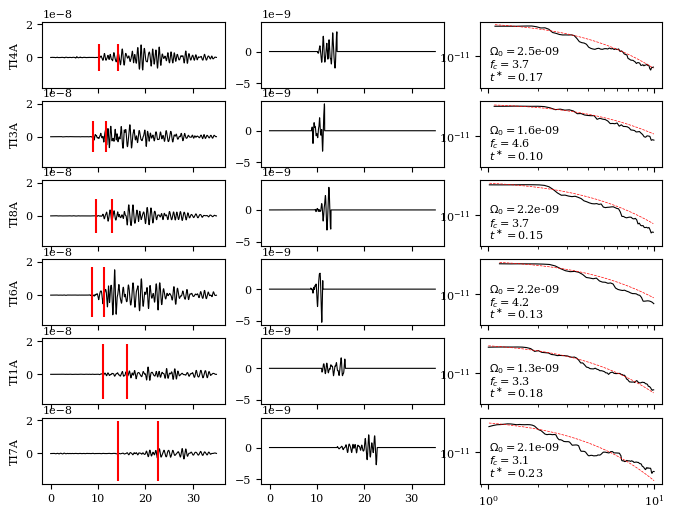

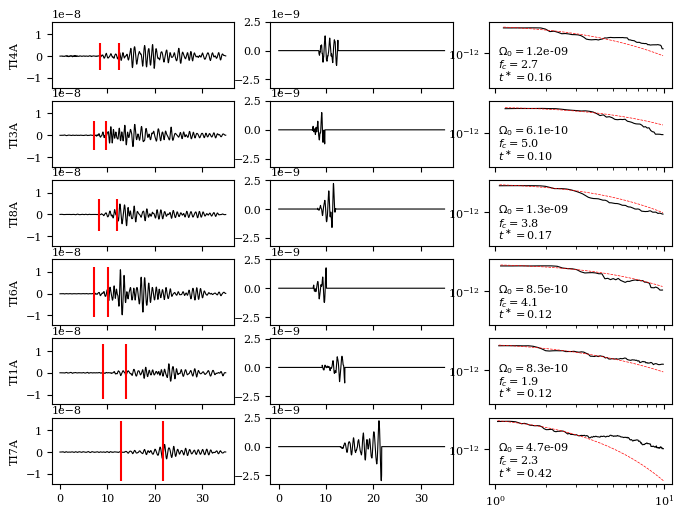

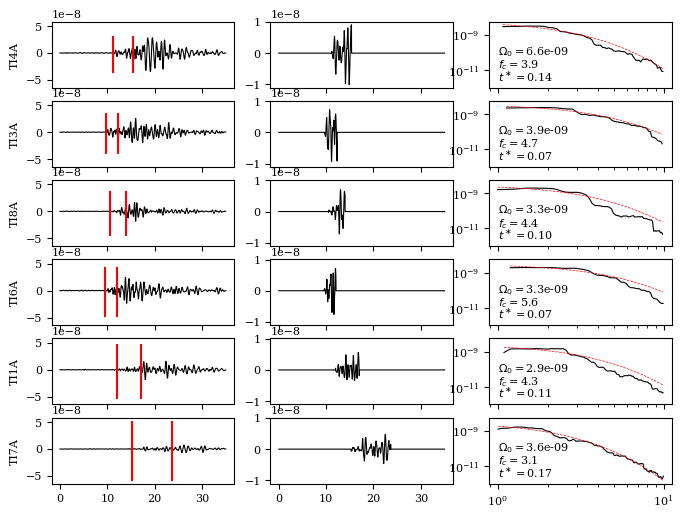

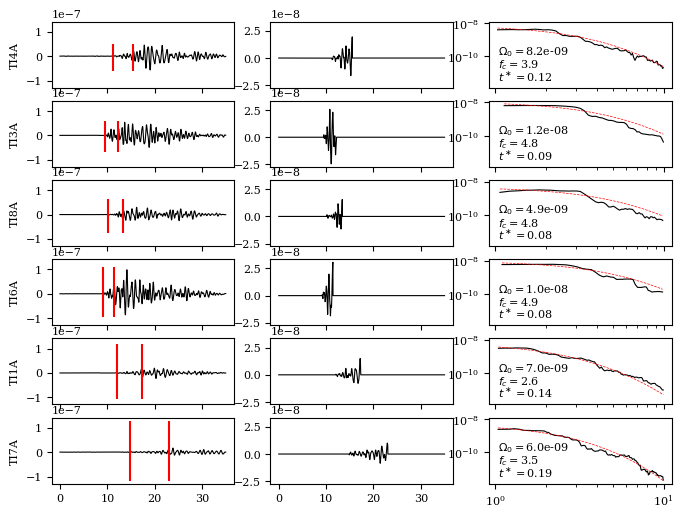

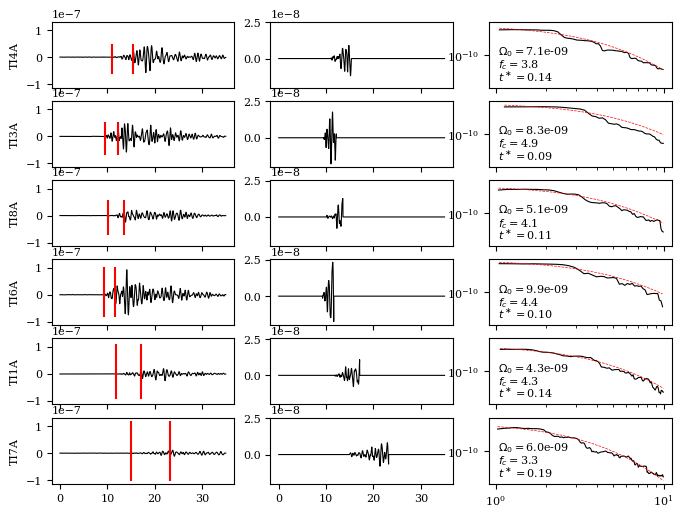

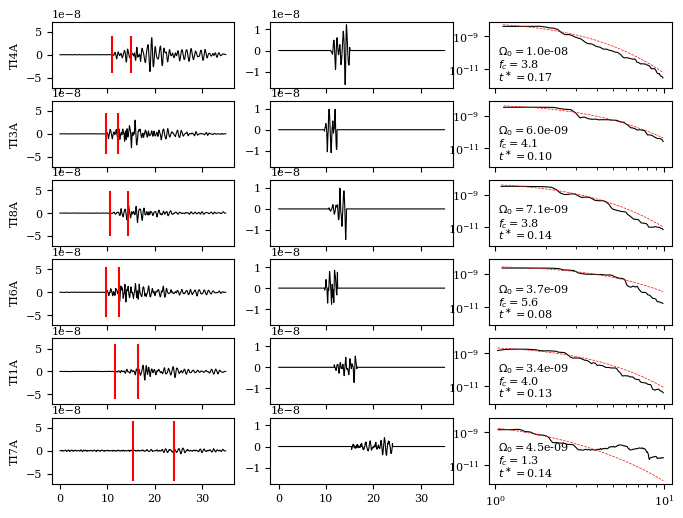

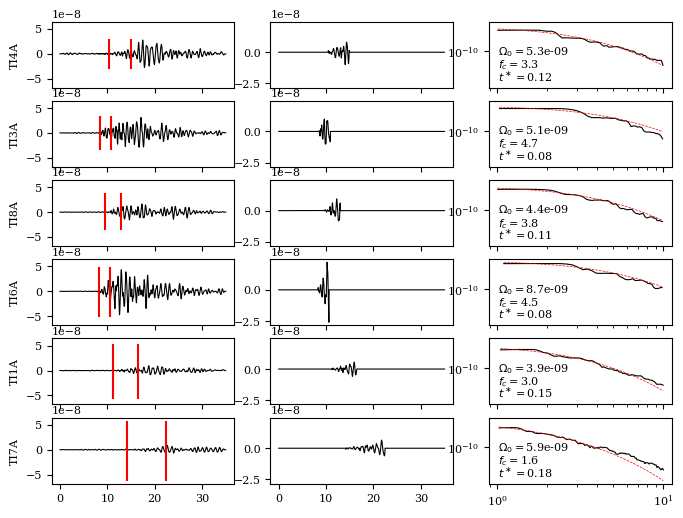

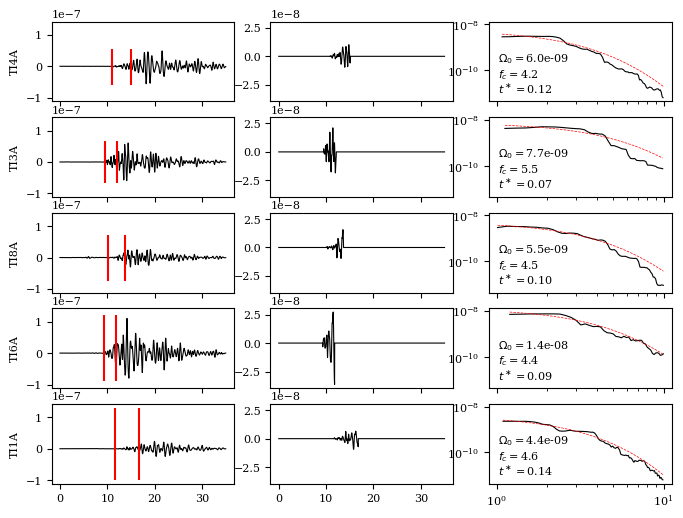

In [103]:
#plot out the fits and see if they make sense...

for cluster_num in groups.keys():
    gamma_xr = xr.load_dataset(os.path.join('/Users/jmagyar/Documents/TottenData','misfit','misfit_surface_'+str(cluster_num)+'.nc'))
    arrivals = mm.Misfit2Arrivals(gamma_xr)

    stations = gamma_xr.stations

    stacked_stream = read(os.path.join('/Users/jmagyar/Documents/TottenData','stacked_waveforms','filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
    stacked_stream.filter('bandpass',freqmin=1,freqmax=10)

    ref_energy = {}

    for tr in stacked_stream:
        if tr.stats.station not in gamma_xr.stations:
            stacked_stream.remove(tr)

    for tr in stacked_stream:
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='DISP')

    fig, ax = plt.subplots(nrows=len(stations),ncols=3,figsize=(8,6),sharex='col',sharey='col')

    #output_df = mm.MomentMagnitudeFitQ(disp_stream,sta_xy,freqmin=1,freqmax=10)
    sta_mag = mm.StationMomentMagnitude(stacked_stream,arrivals,freqmin=1,freqmax=10)
    theta_dict, theta_unc_dict = mm.IncidenceAngle(stacked_stream,arrivals,freqmin=1,freqmax=10)
    f_dict, Pxx_dict, ci_dict, err_dict = mm.SourceSpectrum(stacked_stream,arrivals,freqmin=1,freqmax=10)

    i = 0
    for i, sta_code in enumerate(stations):
        P_start = arrivals['P_start'][sta_code]
        P_end = P_start + arrivals['P_window'][sta_code]
        tr = stacked_stream.select(station=sta_code,channel='CHZ')[0]
        fs = tr.stats.sampling_rate
        ax[i,0].plot(tr.times(),tr.data,color='black',lw=0.8,rasterized=True)
        ylims = ax[i,0].get_ylim()
        ax[i,0].vlines([P_start,P_end],ymin=ylims[0],ymax=ylims[1],color='red')

        N_window = int((P_end - P_start) * fs)
        N_start = int(P_start*fs)
        N_total = tr.data.size

        window = get_window('boxcar',N_window)
        shifted_window = np.pad(window,(N_start,N_total-N_window-N_start))

        ax[i,1].plot(tr.times(),tr.data * shifted_window,color='black',lw=0.8,rasterized=True)



        Pxx = Pxx_dict[sta_code]
        freq = f_dict[sta_code]
        t = (arrivals['R']/3870)[sta_code]


        logomega0 = sta_mag['logomega0'][sta_code]
        fc = sta_mag['fc'][sta_code]
        t_star = sta_mag['t_star'][sta_code]

        omega = mm.LogBruneModel(freq,logomega0,fc,t_star)

        ax[i,2].plot(freq,Pxx,color='black',lw=0.8,rasterized=True)
        ax[i,2].set_xscale('log')
        ax[i,2].set_yscale('log')

        ax[i,2].plot(freq,omega,color='red',ls='--',lw=0.5,rasterized=True)
        ax[i,2].annotate(r'$\Omega_0=${:.1e}'.format(np.exp(logomega0)),(0.05,0.5),xycoords='axes fraction')
        ax[i,2].annotate(r'$f_c=${:.1f}'.format(fc),(0.05,0.3),xycoords='axes fraction')
        ax[i,2].annotate(r'$t^\ast=${:.2f}'.format(t_star),(0.05,0.1),xycoords='axes fraction')

        ax[i,0].set_ylabel(sta_code)

    fig.savefig(os.path.join(p_path,'brune_fit_cluster_' + str(cluster_num) + '.pdf'),bbox_inches='tight')


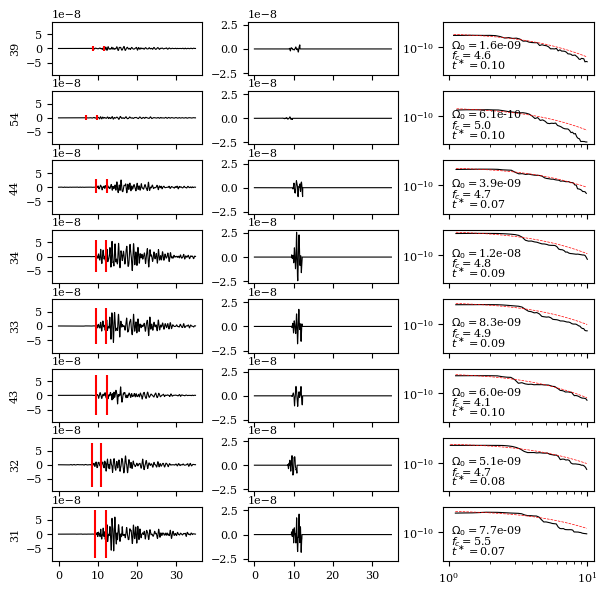

In [104]:
#as above but with single station and for each cluster in the same plot
fig, ax = plt.subplots(nrows=len(groups),ncols=3,figsize=(7,7),sharex='col',sharey='col',gridspec_kw={'wspace':0.3,'hspace':0.3})
sta_code = 'TI3A'

for i, cluster_num in enumerate(groups.keys()):
    gamma_xr = xr.load_dataset(os.path.join('/Users/jmagyar/Documents/TottenData','misfit','misfit_surface_'+str(cluster_num)+'.nc'))
    arrivals = mm.Misfit2Arrivals(gamma_xr)

    stations = gamma_xr.stations

    stacked_stream = read(os.path.join('/Users/jmagyar/Documents/TottenData','stacked_waveforms','filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
    stacked_stream.filter('bandpass',freqmin=1,freqmax=10)

    ref_energy = {}

    for tr in stacked_stream:
        if tr.stats.station not in gamma_xr.stations:
            stacked_stream.remove(tr)

    for tr in stacked_stream:
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='DISP')


    #output_df = mm.MomentMagnitudeFitQ(disp_stream,sta_xy,freqmin=1,freqmax=10)
    sta_mag = mm.StationMomentMagnitude(stacked_stream,arrivals,freqmin=1,freqmax=10)
    theta_dict, theta_unc_dict = mm.IncidenceAngle(stacked_stream,arrivals,freqmin=1,freqmax=10)
    f_dict, Pxx_dict, ci_dict, err_dict = mm.SourceSpectrum(stacked_stream,arrivals,freqmin=1,freqmax=10)


    P_start = arrivals['P_start'][sta_code]
    P_end = P_start + arrivals['P_window'][sta_code]
    tr = stacked_stream.select(station=sta_code,channel='CHZ')[0]
    fs = tr.stats.sampling_rate
    ax[i,0].plot(tr.times(),tr.data,color='black',lw=0.8,rasterized=True)
    ylims = ax[i,0].get_ylim()
    ax[i,0].vlines([P_start,P_end],ymin=ylims[0],ymax=ylims[1],color='red')

    N_window = int((P_end - P_start) * fs)
    N_start = int(P_start*fs)
    N_total = tr.data.size

    window = get_window('boxcar',N_window)
    shifted_window = np.pad(window,(N_start,N_total-N_window-N_start))

    ax[i,1].plot(tr.times(),tr.data * shifted_window,color='black',lw=0.8,rasterized=True)



    Pxx = Pxx_dict[sta_code]
    freq = f_dict[sta_code]
    t = (arrivals['R']/3870)[sta_code]


    logomega0 = sta_mag['logomega0'][sta_code]
    fc = sta_mag['fc'][sta_code]
    t_star = sta_mag['t_star'][sta_code]

    omega = mm.LogBruneModel(freq,logomega0,fc,t_star)

    ax[i,2].plot(freq,Pxx,color='black',lw=0.8,rasterized=True)
    ax[i,2].set_xscale('log')
    ax[i,2].set_yscale('log')

    ax[i,2].plot(freq,omega,color='red',ls='--',lw=0.5,rasterized=True)
    ax[i,2].annotate(r'$\Omega_0=${:.1e}'.format(np.exp(logomega0)),(0.05,0.5),xycoords='axes fraction')
    ax[i,2].annotate(r'$f_c=${:.1f}'.format(fc),(0.05,0.3),xycoords='axes fraction')
    ax[i,2].annotate(r'$t^\ast=${:.2f}'.format(t_star),(0.05,0.1),xycoords='axes fraction')

    ax[i,0].set_ylabel(cluster_num)

#fig.savefig(os.path.join(p_path,'brune_fit_cluster_' + str(cluster_num) + '.pdf'),bbox_inches='tight')

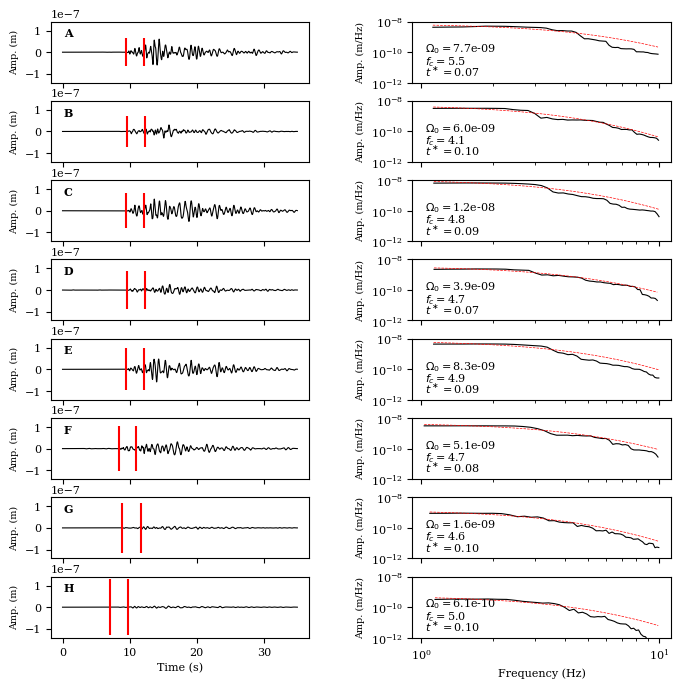

In [129]:
fig, ax = plt.subplots(nrows=len(groups),ncols=2,figsize=(8,8),sharex='col',sharey='col',gridspec_kw={'wspace':0.4,'hspace':0.3})
sta_code = 'TI3A'

i = 0
for cluster_num, label in temp_labels.items():
    cluster_num = int(cluster_num)

    gamma_xr = xr.load_dataset(os.path.join('/Users/jmagyar/Documents/TottenData','misfit','misfit_surface_'+str(cluster_num)+'.nc'))
    arrivals = mm.Misfit2Arrivals(gamma_xr)

    stations = gamma_xr.stations

    stacked_stream = read(os.path.join('/Users/jmagyar/Documents/TottenData','stacked_waveforms','filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
    stacked_stream.filter('bandpass',freqmin=1,freqmax=10)

    ref_energy = {}

    for tr in stacked_stream:
        if tr.stats.station not in gamma_xr.stations:
            stacked_stream.remove(tr)

    for tr in stacked_stream:
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='DISP')


    #output_df = mm.MomentMagnitudeFitQ(disp_stream,sta_xy,freqmin=1,freqmax=10)
    sta_mag = mm.StationMomentMagnitude(stacked_stream,arrivals,freqmin=1,freqmax=10)
    theta_dict, theta_unc_dict = mm.IncidenceAngle(stacked_stream,arrivals,freqmin=1,freqmax=10)
    f_dict, Pxx_dict, ci_dict, err_dict = mm.SourceSpectrum(stacked_stream,arrivals,freqmin=1,freqmax=10)


    P_start = arrivals['P_start'][sta_code]
    P_end = P_start + arrivals['P_window'][sta_code]
    tr = stacked_stream.select(station=sta_code,channel='CHZ')[0]
    fs = tr.stats.sampling_rate
    ax[i,0].plot(tr.times(),tr.data,color='black',lw=0.8,rasterized=True)
    ylims = ax[i,0].get_ylim()
    ax[i,0].vlines([P_start,P_end],ymin=ylims[0],ymax=ylims[1],color='red')

    ax[i,0].annotate(label,(0.05,0.9),xycoords='axes fraction',va='top',weight='bold')



    Pxx = Pxx_dict[sta_code]
    freq = f_dict[sta_code]
    t = (arrivals['R']/3870)[sta_code]


    logomega0 = sta_mag['logomega0'][sta_code]
    fc = sta_mag['fc'][sta_code]
    t_star = sta_mag['t_star'][sta_code]

    omega = mm.LogBruneModel(freq,logomega0,fc,t_star)

    ax[i,1].plot(freq,Pxx,color='black',lw=0.8,rasterized=True)
    ax[i,1].set_xscale('log')
    ax[i,1].set_yscale('log')

    ax[i,1].plot(freq,omega,color='red',ls='--',lw=0.5,rasterized=True)
    ax[i,1].annotate(r'$\Omega_0=${:.1e}'.format(np.exp(logomega0)),(0.05,0.5),xycoords='axes fraction')
    ax[i,1].annotate(r'$f_c=${:.1f}'.format(fc),(0.05,0.3),xycoords='axes fraction')
    ax[i,1].annotate(r'$t^\ast=${:.2f}'.format(t_star),(0.05,0.1),xycoords='axes fraction')

    ax[i,0].set_ylabel('Amp. (m)',fontsize=7)
    ax[i,1].set_ylabel('Amp. (m/Hz)',fontsize=7)

    ax[i,1].set_ylim(1e-12,1e-8)
    ax[i,1].set_yticks([1e-12,1e-10,1e-8])

    i += 1

ax[-1,0].set_xlabel('Time (s)')
ax[-1,1].set_xlabel('Frequency (Hz)')

fig.savefig(os.path.join(cloud_path,'FigS5_brune_fit_cluster.pdf'),bbox_inches='tight')

In [106]:
f = 4.5 #Hz
omega = 2 * np.pi * f
Vs = 1900
Vr = 0.8*Vs #m/s
R = 0.89 * Vr / omega
A = 2 * np.pi * R**2
print(R,A)

47.845512669936895 14383.424342197919


In [107]:
temp_cat.N

1135

In [108]:

#waveform_atts = chunk.load_csv(os.path.join(c_path,'network'),'template_waveform_attributes')
moment_mags = chunk.load_csv(os.path.join(c_path,'network','filtered'),'moment_magnitude')
#temp_cat.attributes['amp_ratio'] = waveform_atts['amp_ratio']
temp_cat.attributes['Mw'] = moment_mags['Mw']
temp_cat.attributes['M0'] = moment_mags['M0']
#temp_cat.attributes['fc'] = moment_mags['fc']
#temp_cat.attributes['dfc'] = moment_mags['dfc']
groups = temp_cat.group_split()

ss_cat = groups[54] + groups[39] + groups[44] + groups[34] + groups[33] + groups[43] + groups[32] + groups[31]
times = temp_cat.event_times

In [109]:
ind = temp_cat.events[(temp_cat.events['group'] == 116) | (temp_cat.events['group'] == 117)].index
event_times = temp_cat.events.drop(ind)['ref_time'].to_numpy()
event_times = np.array([UTCDateTime(time) for time in event_times],dtype=UTCDateTime)
delta_t = np.diff(event_times)
Mw_dt = temp_cat.attributes.drop(ind)['Mw'].to_numpy()[1:]
delta_t /= (60)

In [110]:
def cb_map(val,cb_min,cb_max):
    mapped = (val - cb_min) / (cb_max - cb_min)
    return mapped

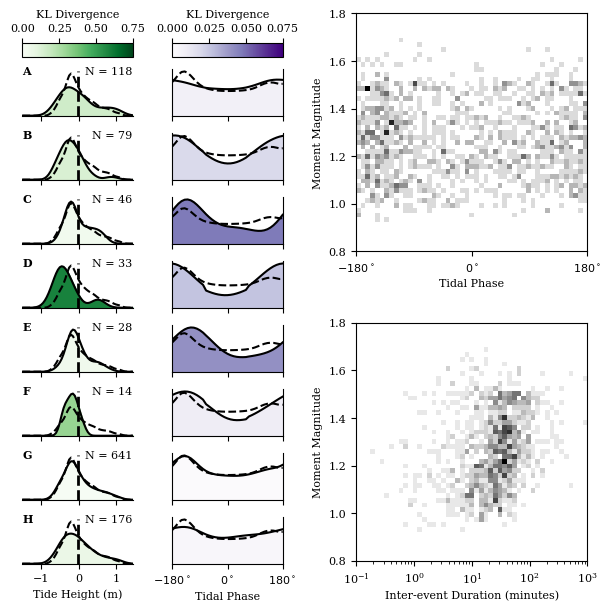

In [124]:
master_fig = plt.figure(figsize=(6,6),layout='constrained')

fig, scatter_fig = master_fig.subfigures(ncols=2)
gs = fig.add_gridspec(ncols=2,nrows=9, height_ratios= [0.3] + 8*[1])

dh = 0.05
height_x = np.mgrid[-1.5:1.5:dh]
ref_tide = gaussian_kde(tide).evaluate(height_x)

dphi = 10
phi = np.mgrid[-300:300:dphi]
ref_phase = gaussian_kde(tidal_phase).evaluate(phi)

neg_excess = ref_phase[phi<-180]
pos_excess = ref_phase[phi>180]
ref_phase[phi.size-neg_excess.size-pos_excess.size:-pos_excess.size] += neg_excess
ref_phase[neg_excess.size:neg_excess.size+pos_excess.size] += pos_excess
ref_phase = ref_phase[neg_excess.size:-pos_excess.size]

cmap_greens = plt.colormaps.get_cmap('Greens')
cmap_reds = plt.colormaps.get_cmap('Purples')

group_KL_height = {'116':np.nan,'117':np.nan}
group_KL_phase = {'116':np.nan,'117':np.nan}

i = 1
for cluster_num, label in ss_temps.items():
    height_ax = fig.add_subplot(gs[i,0])
    phase_ax = fig.add_subplot(gs[i,1])

    comp_tide = gaussian_kde(groups[int(cluster_num)].attributes['height']).evaluate(height_x)
    kl = np.sum(rel_entr(comp_tide,ref_tide)*dh)
    group_KL_height[cluster_num] = kl
    height_ax.plot(height_x,comp_tide,c='black',lw=1.5)
    height_ax.annotate(temp_labels[str(cluster_num)],xy=(0,0.9),xycoords='axes fraction',weight='bold',fontsize=8)
    height_ax.annotate('N = ' + str(groups[int(cluster_num)].N),xy=(1,0.9),xycoords='axes fraction',fontsize=8,ha='right')
    height_ax.fill_between(height_x,comp_tide,color=cmap_greens(cb_map(kl,0,0.75)))
    height_ax.plot(height_x,ref_tide,c='k',lw=1.5,ls='--')

    height_ax.spines['top'].set_visible(False)
    height_ax.spines['left'].set_visible(False)
    height_ax.spines['right'].set_visible(False)
    height_ax.set_yticks([])
    height_ax.vlines(np.mean(tide),ymin=0,ymax=height_ax.get_ylim()[1],lw=2,color='black',ls='--')
    height_ax.set_ylim(bottom=0)
    height_ax.set_xlim(height_x[0],height_x[-1])

    comp_phase = gaussian_kde(groups[int(cluster_num)].attributes['phase']).evaluate(phi)
    neg_excess = comp_phase[phi<-180]
    pos_excess = comp_phase[phi>180]
    comp_phase[phi.size-neg_excess.size-pos_excess.size:-pos_excess.size] += neg_excess
    comp_phase[neg_excess.size:neg_excess.size+pos_excess.size] += pos_excess
    comp_phase = comp_phase[neg_excess.size:-pos_excess.size]
    kl = np.sum(rel_entr(comp_phase,ref_phase)*dphi)
    group_KL_phase[cluster_num] = kl
    phase_ax.plot(phi[neg_excess.size:-pos_excess.size],ref_phase,c='k',lw=1.5,ls='--')
    phase_ax.plot(phi[neg_excess.size:-pos_excess.size],comp_phase,c='black',lw=1.5)
    #phase_ax.annotate(temp_labels[str(cluster_num)],xy=(0,0.9),xycoords='axes fraction',weight='bold',fontsize=12)
    phase_ax.fill_between(phi[neg_excess.size:-pos_excess.size],comp_phase,color=cmap_reds(cb_map(kl,0,0.075)))
    phase_ax.spines['top'].set_visible(False)
    #phase_ax.spines['left'].set_visible(False)
    #phase_ax.spines['right'].set_visible(False)
    phase_ax.set_yticks([])
    phase_ax.set_ylim(bottom=0)
    phase_ax.set_xlim(-180,180)
    phase_ax.set_xticks([-180,0,180],labels=[r'$-180^\circ$',r'$0^\circ$',r'$180^\circ$'])


    if i != 8:
        plt.setp(phase_ax.get_xticklabels(), visible=False)
        plt.setp(height_ax.get_xticklabels(), visible=False)

    else:
        height_ax.set_xlabel('Tide Height (m)')
        phase_ax.set_xlabel('Tidal Phase')

    i += 1

height_cb_ax = fig.add_subplot(gs[0,0])
phase_cb_ax = fig.add_subplot(gs[0,1])

kl1_cb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0,0.75),cmap='Greens'),cax=height_cb_ax,orientation='horizontal')
kl2_cb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0,0.075),cmap='Purples'),cax=phase_cb_ax,orientation='horizontal')

height_cb_ax.xaxis.set_ticks_position('top')
phase_cb_ax.xaxis.set_ticks_position('top')

height_cb_ax.set_xlabel('KL Divergence')
height_cb_ax.xaxis.set_label_position('top')
height_cb_ax.set_xticks([0,0.25,0.5,0.75])

phase_cb_ax.set_xlabel('KL Divergence')
phase_cb_ax.xaxis.set_label_position('top')
phase_cb_ax.set_xticks([0,0.025,0.05,0.075])

gs = scatter_fig.add_gridspec(nrows=2,hspace=0.1)
mag_phi_ax = scatter_fig.add_subplot(gs[0])
mag_dt_ax = scatter_fig.add_subplot(gs[1])
#group_ax = scatter_fig.add_subplot(gs[3],sharex=tide_ts_ax)

#ss_cat.attributes.plot.scatter(ax=mag_phi_ax,x='phase',y='Mw',marker='.',c='green')

phi_bins = np.linspace(-180,180,50)
mag_bins = np.linspace(0.8,1.8,50)
dt_bins = np.logspace(-1,3,50)

mag_phi_hist, _, _ = np.histogram2d(ss_cat.attributes['phase'],ss_cat.attributes['Mw'],(phi_bins,mag_bins))
mag_dt_hist, _, _ = np.histogram2d(delta_t,Mw_dt,(dt_bins,mag_bins))

#mag_phi_ax.scatter(ss_cat.attributes['phase'],ss_cat.attributes['Mw'],marker='.',c='black')
mag_phi_ax.pcolormesh(phi_bins,mag_bins,mag_phi_hist.T,cmap='binary')
mag_phi_ax.set_ylim(0.8,1.8)
mag_phi_ax.set_xticks([-180,0,180],labels=[r'$-180^\circ$',r'$0^\circ$',r'$180^\circ$'])
mag_phi_ax.set_xlabel('Tidal Phase')
mag_phi_ax.set_ylabel('Moment Magnitude')

#mag_dt_ax.scatter(dt,Mw_dt,marker='.',c='black')
mag_dt_ax.pcolormesh(dt_bins,mag_bins,mag_dt_hist.T,cmap='binary')
mag_dt_ax.set_ylim(0.8,1.8)
mag_dt_ax.set_xscale('log')
mag_dt_ax.set_xlabel('Inter-event Duration (minutes)')
mag_dt_ax.set_ylabel('Moment Magnitude')

master_fig.savefig(os.path.join(cloud_path,'Fig4_tidal_modulation.pdf'),bbox_inches='tight',dpi=400)

In [40]:
medM0 = temp_cat.attributes['M0'].median()
D = medM0 / (3e9 * A)
print(D*365*50)
D*100*10

33.17145198478476


1.8176138073854662

In [41]:
rows = []
index = []
for cluster_num, label in temp_labels.items():
    row = {'Label':label,'KL_height':group_KL_height[cluster_num],'KL_phase':group_KL_phase[cluster_num]}
    rows.append(row)
    index.append(cluster_num)

labels_df = pd.DataFrame(data=rows,index=index)
labels_df.to_csv(os.path.join(path,'cluster_Labels.csv'))

In [42]:
labels_df

,Label,KL_height,KL_phase
31,A,0.161477,0.007478
43,B,0.133769,0.018560
34,C,0.029845,0.047244
44,D,0.590058,0.025986
33,E,0.037867,0.040941
32,F,0.302642,0.009385
39,G,0.008124,0.001151
54,H,0.065569,0.003341


## Magnitude Estimates

Simple method to test first is a local magnitude relation which will just need a maximum amplitude and epicentral distance. More complicated but potentially accurate and rigourous method is to get the moment magnitude from the frequency spectra. If this could be done, slip distances etc. could be estimated as this is a physically meaningful quantity. 

If none of the methods seem to give satisfactory results, maimum amplitude is still meaningful and all the events come from approximately the same location so don't strictly need to adjust for spreading and attenuation to get relation between interevent timing and energy release.

#### Relative Amplitude

Even without constraining any absolute estimates of magnitude, the distribution of magnitudes within each group can be understood via the relative amplitude with either the template event, or the stacked waveform. I will later try and estimate the moment magnitude of the stacked waveforms, so I will first try and get the relative amplitude of the group members relative to this stack.

$$
\Delta M_W^{(i)} = \frac{2}{3}\log_{10} \left(\frac{M_0^{(i)}}{\overline{M_0}}\right)
$$

In [115]:
waveform_atts = chunk.load_csv(os.path.join(c_path,'network'),'template_waveform_attributes')
moment_mags = chunk.load_csv(os.path.join(c_path,'network'),'moment_magnitude')
temp_cat.attributes['amp_ratio'] = waveform_atts['amp_ratio']
temp_cat.attributes['Mw'] = moment_mags['Mw']
temp_cat.attributes['M0'] = moment_mags['M0']
temp_cat.attributes['fc'] = moment_mags['fc']
temp_cat.attributes['dfc'] = moment_mags['dfc']
groups = temp_cat.group_split()

In [116]:
groups[43].attributes['Mw'].median()

1.4357112920380404

In [118]:
stacked_streams = {}
for cluster_num in groups.keys():
    stacked_streams[cluster_num] = read(os.path.join(path,'stacked_waveforms','high_stacked_waveforms_cluster_'+str(cluster_num) + '.mseed'))

In [119]:
disp_streams = {}
vel_streams = {}

for cluster_num, stream in stacked_streams.items():
    disp_stream = stream.copy()
    vel_stream = stream.copy()
    for tr in disp_stream.select(station='TI?A'):
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='DISP')
    disp_streams[cluster_num] = disp_stream

    for tr in vel_stream.select(station='TI?A'):
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='VEL')
    vel_streams[cluster_num] = vel_stream

### Moment Magnitude Estimation

Based on the location and time from backmigration, a P window can be approximately picked for each of the stations, although there is still probably scattered P energy occurring after this. Using a spectral method would therefore appear to be a better approach than integrating the displacement curve. The displacement source spectra can be modelled parametrically with

$$
\Omega (f) = \frac{\Omega_0 e^{-\pi f t / Q}}{1 + (f/f_c)^2} 
$$

where $\Omega_0$ is the asymptotic low frequency limit, $f_c$ is the corner frequency, and $Q$ is the attenuation quality factor. These three parameters can be fit to the true displacement spectra, although it may be sensible to set a fixed quality factor based on the medium. The corner frequency is not particularly important for this study, and the main goal is to fit $\Omega_0$. Once this has been found, it can be related to the moment magnitude via

$$
M_0 = \frac{4\pi \rho v^2 r \Omega_0}{A_{rad} C}
$$
where $A_{rad}$ will be the P-wave radiation pattern factor (choose a constant averaged value such as 0.44 as we are not inverting for source mechanism), and $C$ is the free surface correction term

$$
C = 2\cos(\theta)
$$

with $\theta$ being the incidence angle. This moment magnitude is of physical relevance, and can be related to the slip geometry via

$$
M_0 = \mu D S
$$

where $\mu$ is the shear modulus, $D$ is the slip distance, and $S$ is the slip area. The best way to interpret the magnitude of the events is via the magnitude scale given by

$$
M_W = \frac{2}{3}\log_{10} (M_0) - 6.0
$$

This can be done for each station and some average taken with the spread used to quantify uncertainty. 


It seems difficult to fit the spectra of individual events due to the ocean microseisms affecting the lower frequencies. The best approach therefore may be to fit the stacked event spectra, then use amplitude ratios with this template trace to estimate the magnitude of all other events in the cluster.

#### Selecting P Wave Window

In [ ]:
def get_sta_xy_df(inv):

    rows = []
    labels = []

    for net in inv:
        for sta in net:
            row = {'Latitude':sta.latitude,'Longitude':sta.longitude,'Depth':-sta.elevation/1000}
            rows.append(row)
            labels.append(sta.code)
    
    df = pd.DataFrame(data=rows,index=labels)

    centre = df.mean(axis=0)

    df['rLatitude'] = df['Latitude'] - centre['Latitude']
    df['rLongitude'] = df['Longitude'] - centre['Longitude']

    df['X'] = degrees2kilometers(df['rLongitude'].to_numpy(),radius=6371.0*np.cos(np.deg2rad(centre['Latitude'])))
    df['Y'] = degrees2kilometers(df['rLatitude'])
    df['Z'] = df['Depth']

    return df, centre

The $M_0$ estimate should be consistant across stations as it is a source parameter. I can try to enforce this in the inversion by substituting it into the Brune model and fitting all stations together.

$$
\Omega_0 = \frac{M_0 A_{rad} C}{4\pi \rho v^2 r}
$$

This can then be substituted into the Brune model to give

$$
\Omega (f) = \frac{M_0 A_{rad} C}{4\pi \rho v^2 r}\frac{e^{-\pi f t / Q}}{1 + (f/f_c)^2} 
$$

This can then be used to fit each station simultaneously, allowing each station to have it's own corner frequency and quality factor, but the same $M_0$.

In [ ]:
cluster_num = 33

disp_stream = disp_streams[cluster_num]
vel_stream = vel_streams[cluster_num]

#load in the backmigration results...
icequake_loc = pd.read_csv(os.path.join(coal_path,'backmigration_results.csv'),index_col=0)
row = icequake_loc.loc[cluster_num]

#pick out the cartesian coordinates for the cluster location
x_fit = row['X']
y_fit = row['Y']
z_fit = row['Z']
t_fit = row['t']

sta_xy, centre = get_sta_xy_df(inv.select(station='TI?A'))

sta_xy['diff_X'] = x_fit - sta_xy['X']
sta_xy['diff_Y'] = y_fit - sta_xy['Y']
sta_xy['diff_Z'] = z_fit - sta_xy['Z']

#now get distance and backazimuth from each of the stations
sta_xy['baz_fit'] = np.arctan2(sta_xy['diff_X'],sta_xy['diff_Y'])
sta_xy['r_fit'] = np.sqrt(sta_xy['diff_X']**2 + sta_xy['diff_Y']**2 + sta_xy['diff_Z']**2)
sta_xy['t_fit'] = t_fit

sta_xy['P_start'] = sta_xy['t_fit'] + sta_xy['r_fit']/3.87
sta_xy['P_end'] = sta_xy['t_fit'] + sta_xy['r_fit']/1.90
sta_xy['window'] = sta_xy['P_end'] - sta_xy['P_start']

In [ ]:
groups[cluster_num].events

,stations,ref_time,ref_duration,group
event_id,,,,
20181228T030831Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2018-12-28T03:08:31.798000Z,28.367758,33
20181228T212125Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2018-12-28T21:21:25.038000Z,28.367758,33
20181229T183026Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2018-12-29T18:30:26.228000Z,28.367758,33
20181230T142712Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2018-12-30T14:27:12.524000Z,28.367758,33
20181231T174653Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2018-12-31T17:46:53.430000Z,28.367758,33
20181231T232141Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2018-12-31T23:21:41.870000Z,28.367758,33
20190101T091514Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2019-01-01T09:15:14.752000Z,28.367758,33
20190101T100906Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2019-01-01T10:09:06.640000Z,28.367758,33
20190101T192753Z,"[1J.TI6A., 1J.TI3A., 1J.TI8A., 1J.TI4A.]",2019-01-01T19:27:53.524000Z,28.367758,33


In [ ]:
event = groups[cluster_num].select_event('20190101T192753Z')

#attach waveforms and get velocity and displacement streams...
event.attach_waveforms(inv.select(station='TI?A',channel='CH?'),w_path,buffer=10,length=25)
event.filter('highpass',freq=1)

disp_stream = event.get_data_window()

In [ ]:
coal_file = np.load(os.path.join(coal_path,'coalescence_function_' + str(cluster_num) + '.npz'))
x, y, z, t, coal = coal_file['x'], coal_file['y'], coal_file['z'], coal_file['t'], coal_file['coal']

fit, uncertainties, centres = sa.UncertaintyQuantBackM(x,y,z,t,inv.select(station='TI?A'),coal,contours=[0.75])

arrivals = sa.ArrivalTimes(inv.select(station='TI?A'),fit,uncertainties[0.75])

#### Fitting Brune Model

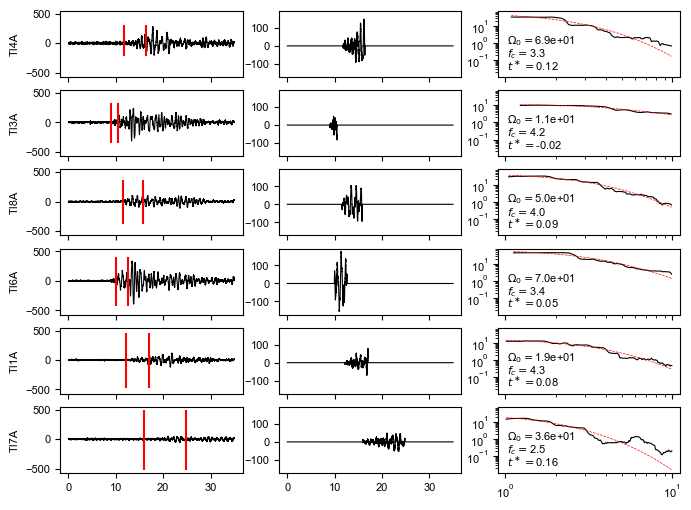

In [ ]:
fig, ax = plt.subplots(nrows=6,ncols=3,figsize=(8,6),sharex='col',sharey='col')

#output_df = mm.MomentMagnitudeFitQ(disp_stream,sta_xy,freqmin=1,freqmax=10)
sta_mag = mm.StationMomentMagnitude(disp_stream,arrivals,freqmin=1,freqmax=10)
theta_dict, theta_unc_dict = mm.IncidenceAngle(disp_stream,arrivals,freqmin=1,freqmax=10)
f_dict, Pxx_dict, ci_dict, err_dict = mm.SourceSpectrum(disp_stream,arrivals,freqmin=1,freqmax=10)

i = 0
for net in inv.select(station='TI?A'):
    for sta in net:
        P_start = arrivals['P_start'][sta.code]
        P_end = P_start + arrivals['window'][sta.code]
        tr = disp_stream.select(station=sta.code,channel='CHZ')[0]
        fs = tr.stats.sampling_rate
        ax[i,0].plot(tr.times(),tr.data,color='black',lw=0.8,rasterized=True)
        ylims = ax[i,0].get_ylim()
        ax[i,0].vlines([P_start,P_end],ymin=ylims[0],ymax=ylims[1],color='red')

        N_window = int((P_end - P_start) * fs)
        N_start = int(P_start*fs)
        N_total = tr.data.size

        window = get_window('boxcar',N_window)
        shifted_window = np.pad(window,(N_start,N_total-N_window-N_start))

        ax[i,1].plot(tr.times(),tr.data * shifted_window,color='black',lw=0.8,rasterized=True)



        Pxx = Pxx_dict[sta.code]
        freq = f_dict[sta.code]
        t = (sta_xy['r_fit']/3.87)[sta.code]


        logomega0 = sta_mag['logomega0'][sta.code]
        fc = sta_mag['fc'][sta.code]
        t_star = sta_mag['t_star'][sta.code]

        omega = mm.LogBruneModel(freq,logomega0,fc,t_star)

        ax[i,2].plot(freq,Pxx,color='black',lw=0.8,rasterized=True)
        ax[i,2].set_xscale('log')
        ax[i,2].set_yscale('log')

        ax[i,2].plot(freq,omega,color='red',ls='--',lw=0.5,rasterized=True)
        ax[i,2].annotate(r'$\Omega_0=${:.1e}'.format(np.exp(logomega0)),(0.05,0.5),xycoords='axes fraction')
        ax[i,2].annotate(r'$f_c=${:.1f}'.format(fc),(0.05,0.3),xycoords='axes fraction')
        ax[i,2].annotate(r'$t^\ast=${:.2f}'.format(t_star),(0.05,0.1),xycoords='axes fraction')

        ax[i,0].set_ylabel(sta.code)
        i += 1

fig.savefig(os.path.join(p_path,'brune_curve_fit.pdf'),bbox_inches='tight')

#### Estimating Magnitude with Uncertainty

In [ ]:
#move this to a script, do for both stacked waveforms and also each individual event...

rows = []
labels = []

for cluster_num, stream in stacked_streams.items():
    #load in the backmigration results...

    row = icequake_loc.loc[cluster_num]
    disp_stream = disp_streams[cluster_num]

    #pick out the cartesian coordinates for the cluster location
    x_fit = row['X']
    y_fit = row['Y']
    z_fit = row['Z']
    t_fit = row['t']

    sta_xy, centre = get_sta_xy_df(inv.select(station='TI?A'))

    sta_xy['diff_X'] = x_fit - sta_xy['X']
    sta_xy['diff_Y'] = y_fit - sta_xy['Y']
    sta_xy['diff_Z'] = z_fit - sta_xy['Z']

    #now get distance and backazimuth from each of the stations
    sta_xy['baz_fit'] = np.arctan2(sta_xy['diff_X'],sta_xy['diff_Y'])
    sta_xy['r_fit'] = np.sqrt(sta_xy['diff_X']**2 + sta_xy['diff_Y']**2 + sta_xy['diff_Z']**2)
    sta_xy['t_fit'] = t_fit

    sta_xy['P_start'] = sta_xy['t_fit'] + sta_xy['r_fit']/3.87
    sta_xy['P_end'] = sta_xy['t_fit'] + sta_xy['r_fit']/1.90
    sta_xy['window'] = sta_xy['P_end'] - sta_xy['P_start']

    Mw, M0 = mm.MomentMagnitude(disp_stream,sta_xy,freqmin=1,freqmax=10)

    row = {'M0':M0,'Mw':Mw}
    rows.append(row)
    labels.append(cluster_num)

mags = pd.DataFrame(data=rows,index=labels)
mags

KeyError: 'R'

In [ ]:
for cluster_num, stream in disp_streams.items():
    for net in inv:
        for sta in net:
            substream = stream.select(network=net.code,station=sta.code,channel='CH?')
            amp_trace = np.linalg.norm(np.stack([tr.data for tr in substream],axis=1),axis=1)
            rel_amp = np.max(amp_trace)
            mags.at[cluster_num,sta.code] = rel_amp

In [ ]:
mags

,M0,Mw,TI4A,TI3A,TI8A,TI6A,TI1A,TI7A
44,(6.8+/-2.0)e+10,1.22+/-0.08,6.866565e-08,6.129649e-08,5.352994e-08,6.496920e-08,2.594385e-08,1.328046e-08
54,(8+/-6)e+09,0.62+/-0.22,2.181084e-08,2.897675e-08,1.795351e-08,2.904167e-08,1.295848e-08,7.116829e-09
39,(2.3+/-1.0)e+10,0.91+/-0.13,2.189494e-08,3.498823e-08,1.990063e-08,3.458611e-08,1.221822e-08,6.345179e-09
34,(1.1+/-0.4)e+11,1.36+/-0.10,1.060814e-07,1.692780e-07,5.958092e-08,1.659705e-07,3.743865e-08,2.298155e-08
33,(8+/-4)e+10,1.26+/-0.14,1.465528e-07,2.271981e-07,8.734383e-08,2.177198e-07,5.467383e-08,2.450230e-08
116,(7.4+/-2.7)e+10,1.25+/-0.11,1.217061e-08,4.687729e-08,2.337234e-08,4.362669e-08,9.857244e-09,1.504782e-08
117,(2.1+/-0.7)e+11,1.55+/-0.09,1.664966e-08,6.139822e-08,3.732350e-08,6.412911e-08,1.335881e-08,3.010374e-08
32,(1.3+/-0.4)e+11,1.40+/-0.09,6.685179e-08,8.217134e-08,2.945107e-08,7.828822e-08,2.475750e-08,1.383642e-08
31,(1.1+/-0.4)e+11,1.35+/-0.10,8.794736e-08,1.678982e-07,4.562631e-08,1.544976e-07,3.675503e-08,NaN
43,(1.03+/-0.34)e+11,1.34+/-0.09,6.368439e-08,8.473740e-08,5.384066e-08,8.568151e-08,2.876969e-08,NaN


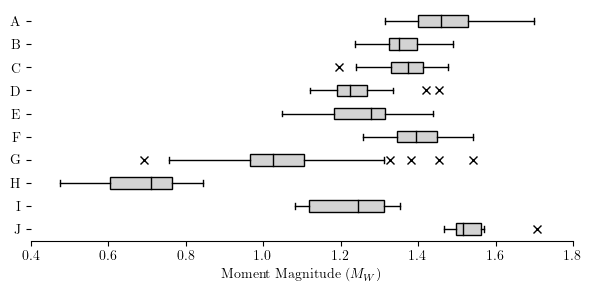

In [ ]:
Mw_lst = []
labels = []
for clust_num in sort_temps.keys():
    group_cat = groups[int(clust_num)]
    Mw_lst.append(group_cat.attributes['Mw'].dropna().to_numpy())
    labels.append(clust_num)

fig = plt.figure(figsize=(7,3))
ax = fig.add_subplot(111)

group_labels = ['A','B','C','D','E','F','G','H','I','J']

bp = ax.boxplot(Mw_lst,labels=labels,vert=False,sym='x',patch_artist=True)
ax.set_yticklabels(group_labels)

for patch in bp['boxes']:
    patch.set_facecolor('lightgrey')

for line in bp['medians']:
    line.set_color('black')

ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel(r'Moment Magnitude ($M_W$)')
ax.invert_yaxis()
ax.set_xlim(0.4,1.8)

fig.savefig(os.path.join(p_path,'magnitude_boxplot.pdf'),bbox_inches='tight')

In [ ]:
groups[34].attributes

,group,similarity,time,diurnal,phase,amp_ratio,Mw
event_id,,,,,,,
20181225T155330Z,34,0.856297,17890.662153,17532.662153,127.677386,0.966311,1.294412
20190101T141318Z,34,0.962296,17897.592576,17532.592569,-164.965812,0.995292,1.344948
20190101T161017Z,34,0.966405,17897.673816,17532.673808,-124.348990,0.857827,1.264708
20190101T164915Z,34,0.956472,17897.700871,17532.700868,-110.781757,0.767451,1.238914
20190101T231121Z,34,0.930156,17897.966219,17532.966215,8.072578,1.067458,1.387235
20190102T003816Z,34,0.982091,17898.026581,17532.026574,25.241557,0.966646,1.326316
20190102T045627Z,34,0.980449,17898.205872,17532.205868,34.811745,0.862918,1.279328
20190102T053545Z,34,0.971536,17898.233163,17532.233160,38.964793,0.803627,1.242245
20190102T094607Z,34,0.980614,17898.407032,17532.407025,95.364439,1.034771,1.343204


#### Combining Event Groups

The spatial distribution shows that there are potentially 2 sticky spots, so we can combine the groups that appear to be operating in each of these locations. Just include the groups that were well located, as these are probably those with lower noise levels, etc.

In [ ]:
west_group = groups[31] + groups[34] + groups[39] + groups[33] #A + C + E + G
east_group = groups[43] + groups[44] #B + D

In [ ]:
#can try plotting the estimated corner frequencies as a histogram, take weighted average with standard errors...
fc_E = east_group.attributes['fc'].to_numpy()
dfc_E = east_group.attributes['dfc'].to_numpy()

ave_fc_E = np.nansum(fc_E/(dfc_E**2)) / np.nansum(1/dfc_E**2)
ave_dfc_E = 1 / np.sqrt(np.nansum(1/dfc_E**2))

fc_W = west_group.attributes['fc'].to_numpy()
dfc_W = west_group.attributes['dfc'].to_numpy()

ave_fc_W = np.nansum(fc_W/(dfc_W**2)) / np.nansum(1/dfc_W**2)
ave_dfc_W = 1 / np.sqrt(np.nansum(1/dfc_W**2))

#can then convert to an estimated radius for each asperity using a rupture velocity
Vr = 400 #m/s
mu = 3e9

omegaE = 2*np.pi*ave_fc_E
omegaW = 2*np.pi*ave_fc_W

rE = 0.89 * Vr / omegaE
rW = 0.89 * Vr / omegaW

aE = np.pi * rE**2
aW = np.pi * rW**2

#then convert to a slip distance for each event using the seismic moment for the event and corresponding asperity area...
east_group.attributes['D'] = 1000 * east_group.attributes['M0'].to_numpy() / (aE * mu)
west_group.attributes['D'] = 1000 * west_group.attributes['M0'].to_numpy() / (aW * mu)

#try plotting the above plot but with the log of the slip distance rather than the moment magnitude. The distribution will be identical as there is common scaling factors, but different for each asperity as different sizes
#also gives a physically meaningful quantity and range for glaciologists, although noting that there is SIGNIFICANT uncertainty on it - explain this in the text...

#make note that even if off by order of magnitude, the distribution is meaningful as this is based essentially on ampltude ratios which is pretty r

print('Eastern Asperity Radius:',rE)
print('Western Asperity Radius:',rW)

Eastern Asperity Radius: 43.2134561324034
Western Asperity Radius: 44.52051631785484


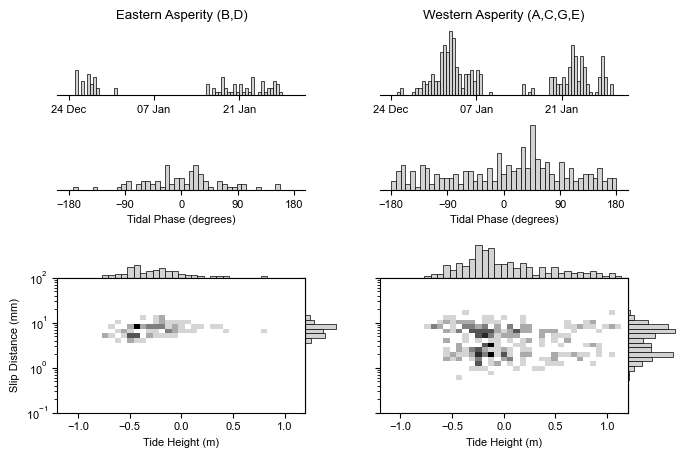

In [ ]:
fig = plt.figure(figsize=(8,5))
gs = fig.add_gridspec(nrows=7,ncols=5,hspace=0,wspace=0,height_ratios=[1,0.4,1,0.4,0.4,0.5,2],width_ratios=[1,0.2,0.1,1,0.2])

east_det_ax = fig.add_subplot(gs[0,0])
west_det_ax = fig.add_subplot(gs[0,3],sharex=east_det_ax,sharey=east_det_ax)

east_tide_ax = fig.add_subplot(gs[2,0])
west_tide_ax = fig.add_subplot(gs[2,3],sharex=east_tide_ax,sharey=east_tide_ax)

east_tide_corner = fig.add_subplot(gs[5,0])
west_tide_corner = fig.add_subplot(gs[5,3],sharex=east_tide_corner,sharey=east_tide_corner)

east_mag_corner = fig.add_subplot(gs[6,1])
west_mag_corner = fig.add_subplot(gs[6,4],sharex=east_mag_corner,sharey=east_mag_corner)

east_scatter_ax = fig.add_subplot(gs[6,0],sharex=east_tide_corner,sharey=east_mag_corner)
west_scatter_ax = fig.add_subplot(gs[6,3],sharex=west_tide_corner,sharey=west_mag_corner)


fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:12*60*60]])

day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(east_group.attributes['time'],bins=fine_bins)

D_bins = np.logspace(-1,2,30)
height_bins = np.linspace(-1.2,1.2,40)


east_det_ax.bar(fine_bins[:-1],temp_hist,width=np.diff(fine_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
east_det_ax.xaxis.set_major_formatter(myFmt)
east_det_ax.xaxis.set_major_locator(HourLocator(interval=4))
east_det_ax.spines['top'].set_visible(False)
east_det_ax.spines['left'].set_visible(False)
east_det_ax.spines['right'].set_visible(False)
east_det_ax.set_yticks([])

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(east_group.attributes['phase'],bins=tide_bins)

east_tide_ax.bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)

east_tide_ax.spines['top'].set_visible(False)
east_tide_ax.spines['left'].set_visible(False)
east_tide_ax.spines['right'].set_visible(False)
east_tide_ax.set_yticks([])
east_tide_ax.set_xlabel('Tidal Phase (degrees)')
east_tide_ax.set_xticks([-180,-90,0,90,180]);


temp_hist, _ = np.histogram(west_group.attributes['time'],bins=fine_bins)


west_det_ax.bar(fine_bins[:-1],temp_hist,width=np.diff(fine_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
west_det_ax.xaxis.set_major_formatter(myFmt)
west_det_ax.xaxis.set_major_locator(HourLocator(interval=4))
west_det_ax.spines['top'].set_visible(False)
west_det_ax.spines['left'].set_visible(False)
west_det_ax.spines['right'].set_visible(False)
west_det_ax.set_yticks([])

temp_hist, _ = np.histogram(west_group.attributes['phase'],bins=tide_bins)

west_tide_ax.bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)

west_tide_ax.spines['top'].set_visible(False)
west_tide_ax.spines['left'].set_visible(False)
west_tide_ax.spines['right'].set_visible(False)
west_tide_ax.set_yticks([])
west_tide_ax.set_xlabel('Tidal Phase (degrees)')
west_tide_ax.set_xticks([-180,-90,0,90,180]);

myFmt = DateFormatter("%d %b")
east_det_ax.xaxis.set_major_formatter(myFmt)
east_det_ax.xaxis.set_major_locator(DayLocator(interval=14))

east_scatter_ax.set_yscale('log')
west_scatter_ax.set_yscale('log')

east_hist, _, _ = np.histogram2d(east_group.attributes['height'],east_group.attributes['D'],bins=(height_bins,D_bins))
west_hist, _, _ = np.histogram2d(west_group.attributes['height'],west_group.attributes['D'],bins=(height_bins,D_bins))
east_scatter_ax.pcolormesh(height_bins,D_bins,east_hist.T,cmap='binary')
west_scatter_ax.pcolormesh(height_bins,D_bins,west_hist.T,cmap='binary')

east_scatter_ax.set_ylim(1e-1,1e2)
east_scatter_ax.set_xlabel('Tide Height (m)')
west_scatter_ax.set_xlabel('Tide Height (m)')
east_scatter_ax.set_ylabel('Slip Distance (mm)')

east_det_ax.set_title('Eastern Asperity (B,D)')
west_det_ax.set_title('Western Asperity (A,C,G,E)')



mag_hist, _ = np.histogram(east_group.attributes['D'],bins=D_bins)
east_mag_corner.set_yscale('log')
east_mag_corner.barh(D_bins[:-1],mag_hist,height=np.diff(D_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)

mag_hist, _ = np.histogram(west_group.attributes['D'],bins=D_bins)
west_mag_corner.barh(D_bins[:-1],mag_hist,height=np.diff(D_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)
west_mag_corner.set_yscale('log')

height_hist, _ = np.histogram(east_group.attributes['height'],bins=height_bins)
east_tide_corner.bar(height_bins[:-1],height_hist,width=np.diff(height_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)

height_hist, _ = np.histogram(west_group.attributes['height'],bins=height_bins)
west_tide_corner.bar(height_bins[:-1],height_hist,width=np.diff(height_bins),align='edge',facecolor='lightgrey',edgecolor='black',lw=0.5)

west_tide_corner.spines['top'].set_visible(False)
west_tide_corner.spines['left'].set_visible(False)
west_tide_corner.spines['right'].set_visible(False)
west_tide_corner.set_yticks([])

east_tide_corner.spines['top'].set_visible(False)
east_tide_corner.spines['left'].set_visible(False)
east_tide_corner.spines['right'].set_visible(False)

west_mag_corner.spines['top'].set_visible(False)
west_mag_corner.spines['bottom'].set_visible(False)
west_mag_corner.spines['right'].set_visible(False)
west_mag_corner.set_xticks([])

east_mag_corner.spines['top'].set_visible(False)
east_mag_corner.spines['bottom'].set_visible(False)
east_mag_corner.spines['right'].set_visible(False)

plt.setp(west_scatter_ax.get_yticklabels(), visible=False)
plt.setp(east_mag_corner.get_yticklabels(), visible=False)
plt.setp(west_mag_corner.get_yticklabels(), visible=False)


fig.savefig(os.path.join(p_path,'density_eastwest_summary.pdf'),bbox_inches='tight')

In [ ]:
#plot split into high and low tide favoured groups...
cluster_labels

NameError: name 'cluster_labels' is not defined